# 2×5 URA Panel — Ideal-Condition Beamforming Baseline

**Array:** 10 hydrophones in a 2 × 5 uniform rectangular array (URA), uniform separation
**d = 0.83 m** on both axes. This is the PT PAL panel, the counterpart to the 9-element ring
analysed in the sibling `BEAMFORM_LEN` project.

> **Ideal conditions.** Perfect elements, spatially white noise, c = 1500 m/s everywhere, and
> far-field sources with no host platform and no multipath. This notebook is the **upper
> bound** and the regression suite — its closed-form results are asserted on every run. It is
> not a performance prediction.

### Geometry and conventions

The panel stands **upright**, facing azimuth 0°:

```
        front view  (looking at the panel)          top view

    row 2   o     o     o     o     o              o o o o o      ^ +Y
            |                       |              ----------     |
    row 1   o     o     o     o     o           panel edge-on     +---> +X  (broadside,
            |<------- 3.32 m ------>|                                        azimuth 0)
            d = 0.83 m between elements
```

* The panel lies in the **Y–Z plane**; its normal (broadside) is **+X = azimuth 0°**.
* **Long axis = Y**, 5 elements, 3.32 m aperture → this is the **azimuth** aperture.
* **Stack axis = Z** (vertical), 2 elements, 0.83 m aperture → **coarse elevation** only.
* Azimuth is measured in the X–Y plane from +X toward +Y; elevation is positive upward.
* The panel is **back-baffled**: arrivals from behind are attenuated before reaching the
  elements. This is what makes the array usable at all — see §5.

### Why this array behaves nothing like the ring

| | 9-element ring (BEAMFORM_LEN) | **2×5 panel (this notebook)** |
|---|---|---|
| Azimuth coverage | full 360°, pattern identical at every steer | **a forward sector only** (§14) |
| Ambiguity | up/down (above vs below the ring plane) | front/back (azimuth φ vs 180°−φ), **removed by the back baffle** (§5) |
| Peak sidelobe | −7.9 dB, intrinsic to a ring | **−12.0 dB**, and tapers improve it further (§13) |
| Amplitude taper | makes the pattern **worse** | **works as the textbook says** (§13) |
| Spatial sampling | d = λ/2 at 1754 Hz | **d = λ/2 at just 904 Hz** (§15) |

### Contents

| § | Topic |
|---|---|
| 1–2 | Geometry and visualisation |
| 3 | DAS beamformer core, with regression self-tests |
| 4 | Beam pattern at broadside — azimuth, polar and elevation cuts |
| 5 | **Front/back ambiguity and the back baffle** — the rejection budget |
| 6 | **Vertical response** — the 2-element stack and its zenith null |
| 7–8 | Resolution: two-source test, and resolution vs frequency |
| 9 | The broadband phase-mismatch problem |
| 10–11 | MVDR, and DAS vs MVDR broadband |
| 12 | Interactive explorer |
| 13 | **Amplitude taper — it works on a URA** |
| 14 | **Steering: beam broadening and the usable sector** |
| 15 | **Spatial aliasing — the 904 Hz and 1807 Hz thresholds** |
| 16–17 | Ship-noise model and bearing tracking |
| 18 | Summary and side-by-side comparison with the ring |

> **Dependencies**: `numpy`, `scipy`, `matplotlib`, `pyyaml`, `ipywidgets` (optional)


## 1. Array Geometry

*Ideal baseline — supports: channel map for FAT.*

Everything downstream follows from two numbers: the **element spacing d = 0.83 m** and the
**element count on each axis**. The spacing alone fixes the spatial-sampling limit at
c/2d; the 5-element long axis fixes the azimuth beamwidth; the 2-element stack means there
is essentially no vertical beam to speak of.

In [1]:
import sys
from functools import partial
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ura2x5.io import load_config
from ura2x5 import geometry

CFG        = load_config(REPO_ROOT / "config.yaml")
C_WATER    = CFG["environment"]["c_water"]
F0         = CFG["design"]["f0_hz"]
LAMBDA0    = C_WATER / F0
STEER_EL   = CFG["design"]["steer_el_deg"]
STEER_AZ   = CFG["design"]["steer_az_deg"]
PHASE_BITS = CFG["design"]["phase_bits"]
BAND       = tuple(CFG["design"]["band_hz"])

BAFFLE     = CFG["baffle"]
FBR_DB     = BAFFLE["front_to_back_db"]       # front-to-back rejection of the back baffle
FBR_TRANS  = BAFFLE["transition_deg"]

N_LONG  = CFG["array"]["n_long"]
N_STACK = CFG["array"]["n_stack"]
D_ELEM  = CFG["array"]["d_m"]
pos, labels, idx = geometry.build_ura(N_LONG, N_STACK, D_ELEM)
N = pos.shape[0]

geo          = geometry.ura_derived(pos, D_ELEM, C_WATER, N_LONG, N_STACK)
AP_LONG      = geo["aperture_long"]
AP_STACK     = geo["aperture_stack"]
F_ALIAS      = geo["f_alias"]            # d = lambda/2, alias-free at EVERY steer below this
F_ALIAS_BS   = C_WATER / D_ELEM          # d = lambda, aliased even at broadside above this
F_LAMBDA_D   = geo["f_lambda_eq_D"]
dmat         = geo["dmat"]

print(f"Elements                      : {N}  ({N_LONG} long x {N_STACK} stacked)")
print(f"Element separation d          : {D_ELEM:.4f} m")
print(f"Long aperture  (Y, azimuth)   : {AP_LONG:.4f} m   ({N_LONG} elements)")
print(f"Stack aperture (Z, elevation) : {AP_STACK:.4f} m   ({N_STACK} elements)")
print(f"Max pairwise distance         : {geo['D_max']:.4f} m")
print()
print(f"d = lambda/2  (alias-free at ANY steer below) : {F_ALIAS:.1f} Hz")
print(f"d = lambda    (aliased even at broadside above): {F_ALIAS_BS:.1f} Hz")
print(f"lambda = long aperture                        : {F_LAMBDA_D:.1f} Hz")
print(f"d/lambda at f0 = {F0:.0f} Hz                      : {D_ELEM*F0/C_WATER:.4f}")
print(f"White-noise array gain 10log10(N)             : {10*np.log10(N):.2f} dB")
print(f"Back baffle, front-to-back rejection          : {FBR_DB:.0f} dB (placeholder)")
print()
print(" Idx  Label      X (m)      Y (m)      Z (m)")
for i in range(N):
    print(f"{idx[i]:>4}  {labels[i]:<5} {pos[i,0]:>9.4f} {pos[i,1]:>10.4f} {pos[i,2]:>10.4f}")

assert abs(F_ALIAS - 903.6) < 0.5, "Regression: d = lambda/2 should fall at ~903.6 Hz"
assert abs(AP_LONG - 3.32) < 1e-9, "Regression: long aperture should be 4d = 3.32 m"


Elements                      : 10  (5 long x 2 stacked)
Element separation d          : 0.8300 m
Long aperture  (Y, azimuth)   : 3.3200 m   (5 elements)
Stack aperture (Z, elevation) : 0.8300 m   (2 elements)
Max pairwise distance         : 3.4222 m

d = lambda/2  (alias-free at ANY steer below) : 903.6 Hz
d = lambda    (aliased even at broadside above): 1807.2 Hz
lambda = long aperture                        : 451.8 Hz
d/lambda at f0 = 904 Hz                      : 0.5002
White-noise array gain 10log10(N)             : 10.00 dB
Back baffle, front-to-back rejection          : 20 dB (placeholder)

 Idx  Label      X (m)      Y (m)      Z (m)
   1  r1c1     0.0000    -1.6600    -0.4150
   2  r1c2     0.0000    -0.8300    -0.4150
   3  r1c3     0.0000     0.0000    -0.4150
   4  r1c4     0.0000     0.8300    -0.4150
   5  r1c5     0.0000     1.6600    -0.4150
   6  r2c1     0.0000    -1.6600     0.4150
   7  r2c2     0.0000    -0.8300     0.4150
   8  r2c3     0.0000     0.0000     0.415

## 2. Geometry Visualisation

*Ideal baseline — supports: channel map for FAT.*

The 3D view confirms every element lies in the x = 0 plane. The front view shows the 2 × 5
grid as the wavefront sees it from broadside. The top view shows the panel edge-on, which is
the clearest way to see why a front/back ambiguity is unavoidable: the panel is a flat sheet,
and a flat sheet has two identical sides.

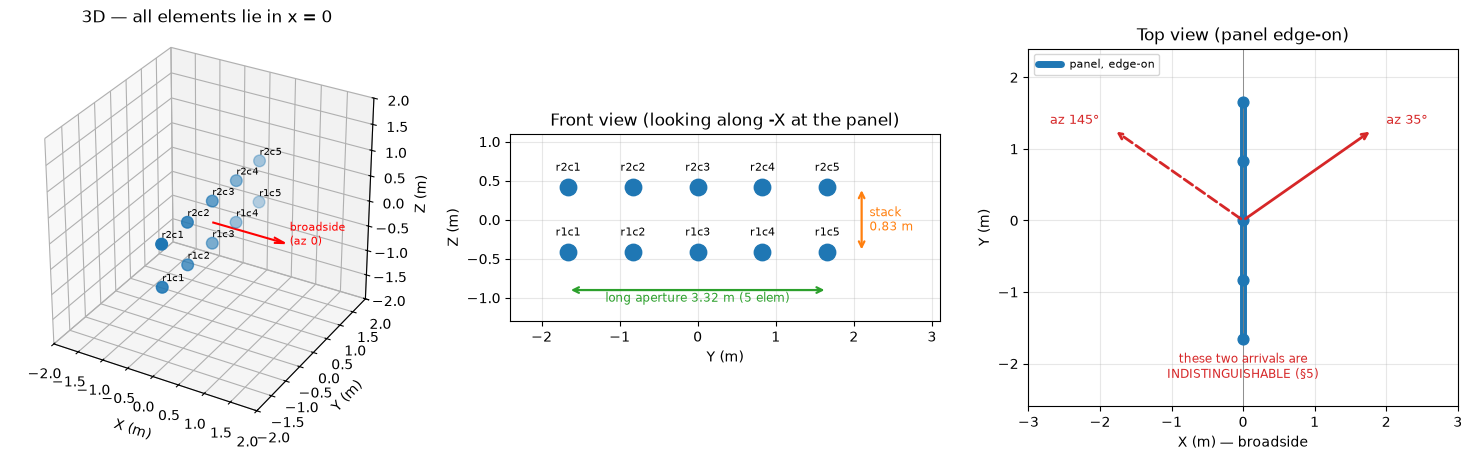

In [2]:
fig = plt.figure(figsize=(15, 4.6))

ax = fig.add_subplot(131, projection='3d')
ax.scatter(*pos.T, c='tab:blue', s=70)
for i, p in enumerate(pos):
    ax.text(p[0], p[1], p[2] + 0.12, labels[i], fontsize=7)
ax.quiver(0, 0, 0, 1.4, 0, 0, color='r', arrow_length_ratio=0.15)
ax.text(1.5, 0, 0, 'broadside\n(az 0)', color='r', fontsize=8)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_zlim(-2, 2)
ax.set_box_aspect([1, 1, 1]); ax.set_title('3D — all elements lie in x = 0')

ax2 = fig.add_subplot(132)
ax2.scatter(pos[:, 1], pos[:, 2], s=140, c='tab:blue', zorder=3)
for i, p in enumerate(pos):
    ax2.annotate(labels[i], (p[1], p[2]), xytext=(0, 12), textcoords='offset points',
                 fontsize=8, ha='center')
ax2.annotate('', xy=(-1.66, -0.9), xytext=(1.66, -0.9),
             arrowprops=dict(arrowstyle='<->', color='tab:green', lw=1.6))
ax2.text(0, -1.05, f'long aperture {AP_LONG:.2f} m ({N_LONG} elem)', ha='center',
         color='tab:green', fontsize=8.5)
ax2.annotate('', xy=(2.1, -0.415), xytext=(2.1, 0.415),
             arrowprops=dict(arrowstyle='<->', color='tab:orange', lw=1.6))
ax2.text(2.2, 0, f'stack\n{AP_STACK:.2f} m', color='tab:orange', fontsize=8.5, va='center')
ax2.set_xlim(-2.4, 3.1); ax2.set_ylim(-1.3, 1.1); ax2.set_aspect('equal')
ax2.set_xlabel('Y (m)'); ax2.set_ylabel('Z (m)'); ax2.grid(alpha=0.3)
ax2.set_title('Front view (looking along -X at the panel)')

ax3 = fig.add_subplot(133)
ax3.plot([0, 0], [-1.66, 1.66], color='tab:blue', lw=5, solid_capstyle='round',
         label='panel, edge-on')
ax3.scatter(np.zeros(N_LONG), pos[:N_LONG, 1], s=60, c='tab:blue', zorder=3)
for phi, col, ls in [(35.0, 'tab:red', '-'), (145.0, 'tab:red', '--')]:
    v = np.array([np.cos(np.radians(phi)), np.sin(np.radians(phi))])
    ax3.annotate('', xy=2.2 * v, xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2, linestyle=ls))
ax3.text(2.0, 1.35, 'az 35°', color='tab:red', fontsize=9)
ax3.text(-2.7, 1.35, 'az 145°', color='tab:red', fontsize=9)
ax3.text(0, -2.2, 'these two arrivals are\nINDISTINGUISHABLE (§5)', ha='center',
         fontsize=8.5, color='tab:red')
ax3.axvline(0, color='gray', lw=0.6)
ax3.set_xlim(-3, 3); ax3.set_ylim(-2.6, 2.4); ax3.set_aspect('equal')
ax3.set_xlabel('X (m) — broadside'); ax3.set_ylabel('Y (m)'); ax3.grid(alpha=0.3)
ax3.set_title('Top view (panel edge-on)'); ax3.legend(fontsize=8, loc='upper left')

plt.tight_layout(); plt.show()


## 3. DAS Beamformer Core

*Ideal baseline — supports: regression check (the closed-form self-tests below are asserted,
not just printed).*

For a far-field plane wave from direction $(\theta,\phi)$ (elevation, azimuth), the steering
vector gives the relative phase at each element:

$$\mathbf{a}(\theta,\phi,f) = \exp\!\left(-j\,2\pi f\,\frac{\hat{\mathbf{k}}\cdot\mathbf{r}_n}{c}\right)$$

**DAS**: $w_n = g_n a_n / \sum g_n$, output $y = \mathbf{w}^H\mathbf{x}$, so a perfectly
aligned signal gives $y = 1$.

This is the same array-agnostic core used for the ring in `BEAMFORM_LEN` — it takes element
positions as an argument, so the two arrays are provably compared on identical code. Only the
geometry module and the taper helper know what shape the array is.

In [3]:
from ura2x5.beamform import (
    steering_vector as _steering_vector,
    quantize_phase,
    das_weights as _das_weights,
    beamformer_output,
    beam_pattern as _beam_pattern,
    to_db_norm,
    lobe_metrics,
    count_peaks_above,
    theta_null_line_deg as _theta_null_line_deg,
    hpbw_line_deg as _hpbw_line_deg,
)
from ura2x5.geometry import (wrap180, unit_vector, mirror_azimuth_deg,
                             baffle_response, required_fbr_db)

steering_vector = partial(_steering_vector, positions=pos, c=C_WATER)
das_weights     = partial(_das_weights, positions=pos, c=C_WATER)

# Azimuth grid centred on broadside so the panel's forward sector is the middle of every plot.
PHI_GRID = np.arange(-180.0, 180.0, 0.2)
FWD = (PHI_GRID >= -90.0) & (PHI_GRID <= 90.0)      # the half-space the panel faces

beam_pattern  = partial(_beam_pattern, phi_grid=PHI_GRID, positions=pos, c=C_WATER)
theta_null_line_deg = partial(_theta_null_line_deg, n=N_LONG, d=D_ELEM, c=C_WATER)
hpbw_line_deg       = partial(_hpbw_line_deg, n=N_LONG, d=D_ELEM, c=C_WATER)


def baffled_pattern(steer_theta, steer_az, freq, **kw):
    """
    Array response vs ARRIVAL direction, including the back baffle.

    The baffle blocks the rear, so each element is a forward-hemisphere receiver. Its
    directivity multiplies the array factor:  B(phi) = |D_elem(phi)|^2 * |w^H a(phi)|^2.
    Inside the forward sector D_elem = 1, so every forward-sector metric (HPBW, sidelobes,
    resolution, steering, aliasing) is identical to the unbaffled array factor.
    """
    g = baffle_response(PHI_GRID, FBR_DB, transition_deg=FBR_TRANS)
    return beam_pattern(steer_theta, steer_az, freq, **kw) * g**2


def fwd_metrics(pdb, steer_az, search=60.0):
    '''
    Main-lobe metrics over the FORWARD half-space only.

    This matters for a panel. The mirror lobe at 180 - steer is an exact copy of the main
    lobe (section 5), so a full 360 scan would report the ambiguity as a 0 dB "sidelobe" and
    every PSL number would be meaningless. The ambiguity is reported separately, as its own
    quantity, rather than smuggled into the sidelobe figure.
    '''
    return lobe_metrics(PHI_GRID[FWD], pdb[FWD], steer_az, circular=False, search=search)


# Self-test: a source exactly at the look direction must give |y| = 1
a_test = steering_vector(STEER_EL, STEER_AZ, F0)
y_ideal = beamformer_output(das_weights(STEER_EL, STEER_AZ, F0), a_test)
print(f"Self-test (ideal phases): |y| = {abs(y_ideal):.4f}  (expect 1.0)")
assert abs(abs(y_ideal) - 1.0) < 1e-9, "Regression: ideal-phase self-test must give |y| = 1"

yq = beamformer_output(das_weights(STEER_EL, STEER_AZ, F0, bits=PHASE_BITS), a_test)
print(f"Self-test ({PHASE_BITS}-bit phases) : |y| = {abs(yq):.4f}  "
      f"-> quantization loss {abs(20*np.log10(abs(yq))):.2f} dB")
print("\nNote: at broadside every element needs zero phase shift, so quantization is exact")
print("here by construction. Section 14 steers off broadside, where it costs something.")


Self-test (ideal phases): |y| = 1.0000  (expect 1.0)
Self-test (3-bit phases) : |y| = 1.0000  -> quantization loss 0.00 dB

Note: at broadside every element needs zero phase shift, so quantization is exact
here by construction. Section 14 steers off broadside, where it costs something.


## 4. Beam Pattern at Broadside

*Ideal baseline — supports: SYS-003 equivalent.*

The 5-element long axis behaves as a uniform line array. Its array factor is
$\mathrm{AF}(\psi) = \dfrac{\sin(N\psi/2)}{N\sin(\psi/2)}$ with
$\psi = kd(\sin\phi - \sin\phi_s)$, which puts

* **nulls** at $\sin\phi - \sin\phi_s = m\lambda/(Nd)$ — note $Nd$, not $(N-1)d$;
* **HPBW** $\approx 0.886\,\lambda/(Nd\cos\phi_s)$;
* a **peak sidelobe near −13 dB** for a long uniform line, slightly higher for only 5 elements.

The panel is **back-baffled**, so each element is a forward-hemisphere receiver and the
baffle's directivity multiplies the array factor. The 360° cut below therefore shows the rear
lobe **suppressed**: nothing behind the panel reaches the elements. The bare array factor is
drawn alongside it to show what the baffle is removing — that rear lobe is the front/back
ambiguity, and §5 covers what survives of it.

Inside the forward sector the baffle is unity, so **every forward-sector metric below — HPBW,
sidelobes, resolution, steering, aliasing — is unchanged by it.**

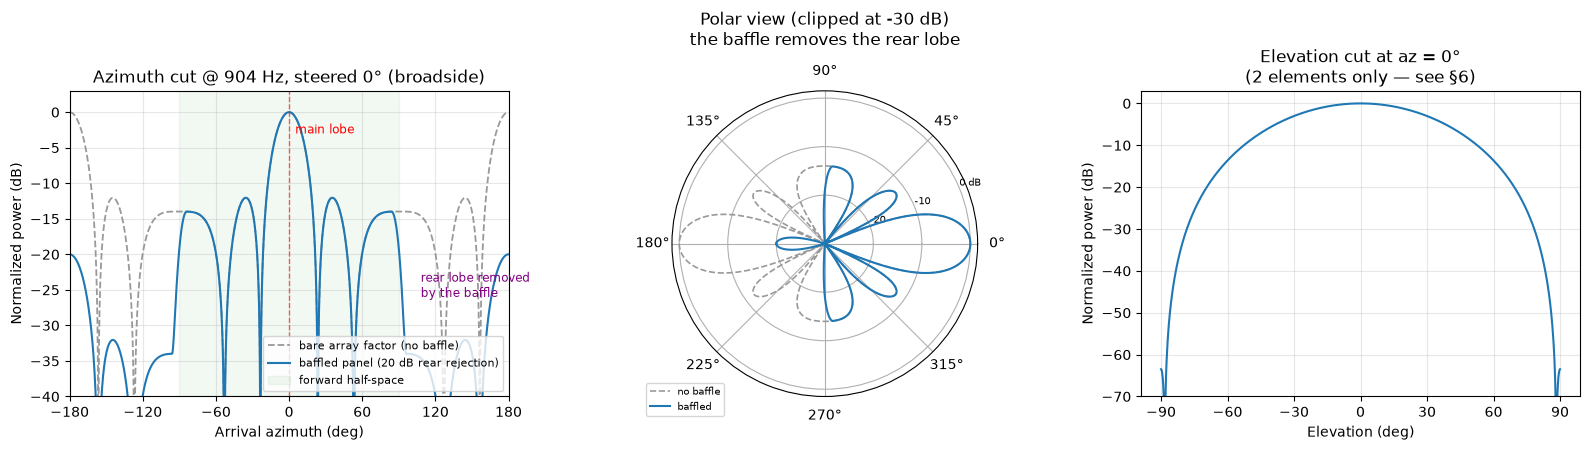

Forward half-space metrics @ 904 Hz, broadside:
  peak              : -0.00°
  HPBW              : 20.60°   (theory 0.886*lambda/Nd = 20.30°)
  first null at     : ±23.60°  (theory asin(lambda/Nd) = 23.57°)
  peak sidelobe     : -12.04 dB  (long uniform line -> -13.2 dB)

Vertical HPBW      : 59.8°  — a 2-element stack barely forms a beam

Rear response: bare array factor peaks at +0.0 dB behind the
panel; with the baffle that falls to -19.2 dB. Nothing astern is heard.
Forward-sector metrics are identical either way (the baffle is unity there):
  HPBW  20.60° (no baffle) vs 20.60° (baffled)
  PSL   -12.04 dB (no baffle) vs -12.04 dB (baffled)


In [4]:
p_af     = beam_pattern(STEER_EL, STEER_AZ, F0)          # bare array factor
p_ideal  = baffled_pattern(STEER_EL, STEER_AZ, F0)       # what the baffled panel responds to
pdb_af   = to_db_norm(p_af)
pdb_i    = to_db_norm(p_ideal)
m_i      = fwd_metrics(pdb_i, STEER_AZ)

# Elevation cut through the beam, at the steered azimuth
el_grid = np.linspace(-90, 90, 721)
w0 = das_weights(STEER_EL, STEER_AZ, F0)
pel = np.abs(np.conj(w0) @ steering_vector(el_grid, STEER_AZ, F0))**2
pdb_el = to_db_norm(pel)
m_el = lobe_metrics(el_grid, pdb_el, 0.0, circular=False, search=5)

fig = plt.figure(figsize=(16, 4.6))
ax = fig.add_subplot(131)
ax.plot(PHI_GRID, pdb_af, '--', color='0.6', lw=1.3, label='bare array factor (no baffle)')
ax.plot(PHI_GRID, pdb_i, label=f'baffled panel ({FBR_DB:.0f} dB rear rejection)')
ax.axvspan(-90, 90, color='green', alpha=0.05, label='forward half-space')
ax.axvline(STEER_AZ, color='r', ls='--', alpha=0.6, lw=1)
ax.annotate('main lobe', (STEER_AZ + 5, -3), fontsize=8.5, color='r')
ax.annotate('rear lobe removed\nby the baffle', (108, -26), fontsize=8.5, color='purple')
ax.set_xlim(-180, 180); ax.set_ylim(-40, 3); ax.set_xticks(range(-180, 181, 60))
ax.set_xlabel('Arrival azimuth (deg)'); ax.set_ylabel('Normalized power (dB)')
ax.set_title(f'Azimuth cut @ {F0:.0f} Hz, steered {STEER_AZ:.0f}° (broadside)')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)

axp = fig.add_subplot(132, projection='polar')
axp.plot(np.radians(PHI_GRID), np.clip(pdb_af, -30, 0) + 30, '--', color='0.6', lw=1.2,
         label='no baffle')
axp.plot(np.radians(PHI_GRID), np.clip(pdb_i, -30, 0) + 30, label='baffled')
axp.set_theta_zero_location('E'); axp.set_yticks([10, 20, 30])
axp.set_yticklabels(['-20', '-10', '0 dB'], fontsize=7)
axp.set_title('Polar view (clipped at -30 dB)\nthe baffle removes the rear lobe', pad=14)
axp.legend(fontsize=7, loc='lower left', bbox_to_anchor=(-0.1, -0.08))

ax3 = fig.add_subplot(133)
ax3.plot(el_grid, pdb_el)
ax3.set_ylim(-70, 3); ax3.grid(alpha=0.3); ax3.set_xticks(range(-90, 91, 30))
ax3.set_xlabel('Elevation (deg)'); ax3.set_ylabel('Normalized power (dB)')
ax3.set_title(f'Elevation cut at az = {STEER_AZ:.0f}°\n(2 elements only — see §6)')
plt.tight_layout(); plt.show()

print(f"Forward half-space metrics @ {F0:.0f} Hz, broadside:")
print(f"  peak              : {m_i['peak']:.2f}°")
print(f"  HPBW              : {m_i['hpbw']:.2f}°   (theory 0.886*lambda/Nd = {float(hpbw_line_deg(F0)):.2f}°)")
print(f"  first null at     : ±{m_i['null_half']:.2f}°  (theory asin(lambda/Nd) = {float(theta_null_line_deg(F0)):.2f}°)")
print(f"  peak sidelobe     : {m_i['psl']:.2f} dB  (long uniform line -> -13.2 dB)")
print(f"\nVertical HPBW      : {m_el['hpbw']:.1f}°  — a 2-element stack barely forms a beam")

rear = (PHI_GRID < -90) | (PHI_GRID > 90)
print(f"\nRear response: bare array factor peaks at {pdb_af[rear].max():+.1f} dB behind the")
print(f"panel; with the baffle that falls to {pdb_i[rear].max():+.1f} dB. Nothing astern is heard.")
print(f"Forward-sector metrics are identical either way (the baffle is unity there):")
m_af = fwd_metrics(pdb_af, STEER_AZ)
print(f"  HPBW  {m_af['hpbw']:.2f}° (no baffle) vs {m_i['hpbw']:.2f}° (baffled)")
print(f"  PSL   {m_af['psl']:.2f} dB (no baffle) vs {m_i['psl']:.2f} dB (baffled)")
assert abs(m_af['hpbw'] - m_i['hpbw']) < 1e-9, "Regression: the baffle must not alter the forward beam"
assert pdb_i[rear].max() < pdb_af[rear].max() - 15, "Regression: the baffle must suppress the rear"


assert abs(m_i['hpbw'] - 20.6) < 0.5, "Regression: broadside HPBW should be ~20.6 deg"
assert abs(m_i['null_half'] - 23.6) < 0.5, "Regression: first null should be ~23.6 deg"
assert abs(m_i['psl'] - (-12.0)) < 0.5, "Regression: forward-sector PSL should be ~-12.0 dB"


## 5. The Back Baffle — What It Removes, and the One Thing It Does Not

*Ideal baseline — supports: the baffle specification and the display convention.*

The panel is back-baffled: the elements **cannot see behind**. Each one is a
forward-hemisphere receiver, so the array simply does not respond to anything astern (§4).
Operationally this array is a **±90° forward sensor**, and that is the end of the matter for
real sources.

What remains is a property of the *maths*, not of the acoustics, and it is worth being precise
about because the two statements look contradictory:

| | |
|---|---|
| Response vs **arrival** direction | rear **suppressed** — nothing behind is heard (§4) |
| **Scan** of a source ahead | still shows a second peak at 180° − φ |

Both are true. Reflecting through the panel plane maps $\phi \to 180° - \phi$ and leaves every
path length unchanged, so $\mathbf{a}(145°)$ and $\mathbf{a}(35°)$ are **the same vector**.
Steering the beamformer to 145° therefore computes exactly the same number, from the same
data, as steering it to 35°. A source at 35° paints peaks at both — not because anything is
behind the panel, but because *looking* behind is mathematically identical to looking ahead.

**The fix is trivial once stated: do not scan behind.** Restricting the display to ±90°
removes the artifact entirely, and the baffle is what makes that restriction correct — it
guarantees that a peak in the forward sector really did come from ahead.

The remaining engineering question is how good the blocking has to be, since no baffle is
perfect and real ones lose rejection at low frequency. The rest of this section answers it.

1) The rear is blocked -- the array does not respond to anything behind it:
     arrival from   100.0° :  -20.0 dB
     arrival from   135.0° :  -20.0 dB
     arrival from   180.0° :  -20.0 dB
     arrival from  -135.0° :  -20.0 dB

2) But the MANIFOLD is still degenerate, which is why the scan needs a convention:
  steer |  mirror |  |a_front - a_back|
    0.0 |   180.0 |            7.70e-16
   20.0 |   160.0 |            8.01e-16
   45.0 |   135.0 |            0.00e+00
   70.0 |   110.0 |            8.97e-16
  -35.0 |   215.0 |            1.29e-15
     worst: 1.29e-15 -- looking behind is identical to looking ahead,
     so a source AHEAD paints a peak at its mirror bearing too. Scanning only the
     forward sector removes that artifact outright.

3) No baffle is perfect. Residual leakage is budgeted below.


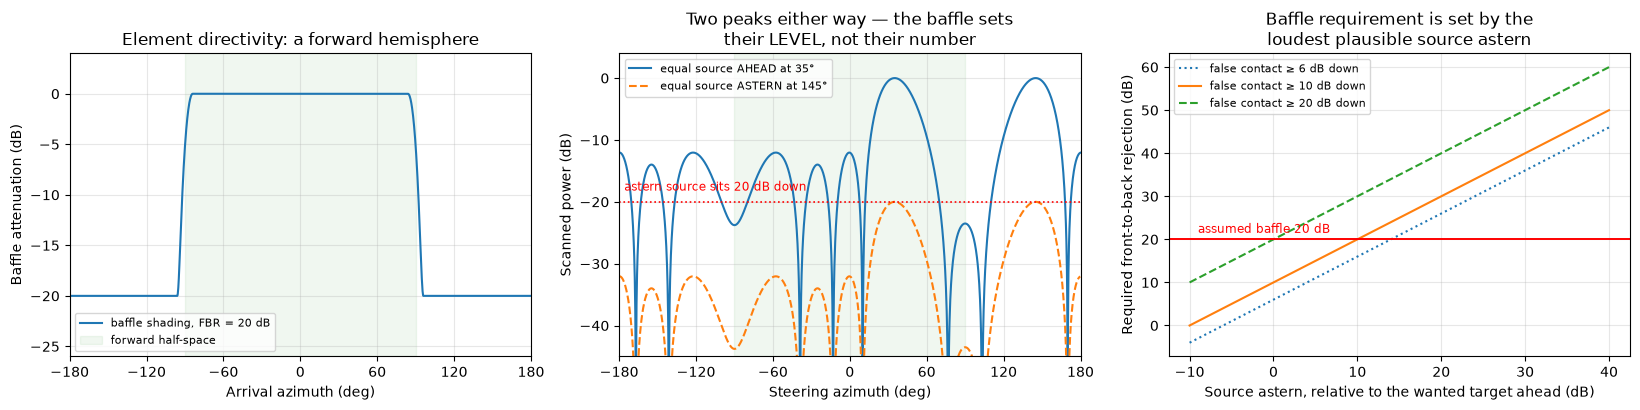


Residual leakage budget -- a source ASTERN, seen through the baffle:
  source astern is |  false contact at |   verdict vs the -12.0 dB sidelobe floor
           +0 dB |          -20.0 dB |                      buried in sidelobes
          +10 dB |          -10.0 dB |               VISIBLE as a false contact
          +20 dB |           +0.0 dB |               VISIBLE as a false contact
          +30 dB |          +10.0 dB |               VISIBLE as a false contact

Design statement: to keep a source 20 dB louder astern at least 10 dB below the
wanted target, the baffle needs >= 30 dB front-to-back rejection. The 20 dB
assumed here is a placeholder -- measure the installed figure, and measure it ACROSS
the band, because baffle performance falls away at low frequency exactly where this
array already has the least azimuth discrimination (section 8).

[OK] Mirror bearing suppressed by 20.0 dB.


In [5]:
from ura2x5.geometry import baffle_response, required_fbr_db

# --- 1. the manifold degeneracy itself, which the baffle does NOT remove -------------
print("1) The rear is blocked -- the array does not respond to anything behind it:")
for p_ in [100.0, 135.0, 180.0, -135.0]:
    gv = float(baffle_response(p_, FBR_DB, transition_deg=FBR_TRANS))
    print(f"     arrival from {p_:7.1f}° : {20*np.log10(gv):+6.1f} dB")

print("\n2) But the MANIFOLD is still degenerate, which is why the scan needs a convention:")
print(f"{'steer':>7} | {'mirror':>7} | {'|a_front - a_back|':>19}")
amb_err = []
for phi_s in [0.0, 20.0, 45.0, 70.0, -35.0]:
    mir = float(mirror_azimuth_deg(phi_s))
    diff = np.max(np.abs(steering_vector(0.0, phi_s, F0) - steering_vector(0.0, mir, F0)))
    amb_err.append(diff)
    print(f"{phi_s:7.1f} | {mir:7.1f} | {diff:19.2e}")
print(f"     worst: {max(amb_err):.2e} -- looking behind is identical to looking ahead,")
print(f"     so a source AHEAD paints a peak at its mirror bearing too. Scanning only the")
print(f"     forward sector removes that artifact outright.")
assert max(amb_err) < 1e-12, "Regression: the front/back pair must be exactly ambiguous"

# --- 2. how good does the blocking have to be? ----------------------------------------
g_baf = baffle_response(PHI_GRID, FBR_DB, transition_deg=FBR_TRANS)
print(f"\n3) No baffle is perfect. Residual leakage is budgeted below.")

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.2))

ax = axes[0]
ax.plot(PHI_GRID, 20*np.log10(g_baf), label=f'baffle shading, FBR = {FBR_DB:.0f} dB')
ax.axvspan(-90, 90, color='green', alpha=0.06, label='forward half-space')
ax.set_xlim(-180, 180); ax.set_xticks(range(-180, 181, 60)); ax.set_ylim(-FBR_DB-6, 4)
ax.set_xlabel('Arrival azimuth (deg)'); ax.set_ylabel('Baffle attenuation (dB)')
ax.set_title('Element directivity: a forward hemisphere')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- 3. what the baffle does, and what it cannot do ----------------------------------
# A single source ALWAYS paints two peaks: the manifold is degenerate and no shading of the
# arrival changes that. What the baffle changes is the LEVEL of the pair for a source astern.
ax = axes[1]
PHI_SRC = 35.0
W = das_weights(0.0, PHI_GRID, F0)
ref = None
for src_az, style, lab in [
        (PHI_SRC, '-', f'equal source AHEAD at {PHI_SRC:.0f}°'),
        (float(mirror_azimuth_deg(PHI_SRC)), '--',
         f'equal source ASTERN at {float(mirror_azimuth_deg(PHI_SRC)):.0f}°')]:
    amp = float(baffle_response(src_az, FBR_DB, transition_deg=FBR_TRANS))
    resp = (amp * np.abs(np.conj(W).T @ steering_vector(0.0, src_az, F0)))**2
    if ref is None:
        ref = resp.max()
    ax.plot(PHI_GRID, 10*np.log10(resp / ref), style, label=lab)
ax.axvspan(-90, 90, color='green', alpha=0.06)
ax.axhline(-FBR_DB, color='r', ls=':', lw=1.2)
ax.annotate(f'astern source sits {FBR_DB:.0f} dB down', (-176, -FBR_DB + 1.8),
            fontsize=8.5, color='r')
ax.set_xlim(-180, 180); ax.set_xticks(range(-180, 181, 60)); ax.set_ylim(-45, 4)
ax.set_xlabel('Steering azimuth (deg)'); ax.set_ylabel('Scanned power (dB)')
ax.set_title('Two peaks either way — the baffle sets\ntheir LEVEL, not their number')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- 4. how much rejection is needed --------------------------------------------------
ax = axes[2]
back_rel = np.linspace(-10, 40, 120)
for margin, ls in [(6.0, ':'), (10.0, '-'), (20.0, '--')]:
    ax.plot(back_rel, required_fbr_db(back_rel, margin), ls,
            label=f'false contact ≥ {margin:.0f} dB down')
ax.axhline(FBR_DB, color='r', lw=1.4)
ax.annotate(f'assumed baffle {FBR_DB:.0f} dB', (-9, FBR_DB + 1.5), fontsize=8.5, color='r')
ax.set_xlabel('Source astern, relative to the wanted target ahead (dB)')
ax.set_ylabel('Required front-to-back rejection (dB)')
ax.set_title('Baffle requirement is set by the\nloudest plausible source astern')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# --- 5. the number to put in the spec --------------------------------------------------
print(f"\nResidual leakage budget -- a source ASTERN, seen through the baffle:")
print(f"{'source astern is':>18} | {'false contact at':>17} | {'verdict vs the -12.0 dB sidelobe floor':>40}")
for rel in [0.0, 10.0, 20.0, 30.0]:
    lvl = rel - FBR_DB
    verdict = 'buried in sidelobes' if lvl < -12.0 else 'VISIBLE as a false contact'
    print(f"{rel:+13.0f} dB | {lvl:+14.1f} dB | {verdict:>40}")

need = float(required_fbr_db(20.0, 10.0))
print(f"\nDesign statement: to keep a source 20 dB louder astern at least 10 dB below the")
print(f"wanted target, the baffle needs >= {need:.0f} dB front-to-back rejection. The {FBR_DB:.0f} dB")
print(f"assumed here is a placeholder -- measure the installed figure, and measure it ACROSS")
print(f"the band, because baffle performance falls away at low frequency exactly where this")
print(f"array already has the least azimuth discrimination (section 8).")

mirror_supp = 20*np.log10(float(baffle_response(float(mirror_azimuth_deg(PHI_SRC)), FBR_DB,
                                                transition_deg=FBR_TRANS)))
assert mirror_supp < -FBR_DB + 1.0, "Regression: the baffle must suppress the mirror bearing"
print(f"\n[OK] Mirror bearing suppressed by {-mirror_supp:.1f} dB.")

## 6. Vertical Response — Two Elements, and a Zenith Null

*Ideal baseline — supports: host-noise rejection (the dominant problem for the ring).*

The stack axis has only **two** elements, so there is no vertical beam in any meaningful
sense: the pattern is the 2-element interferometer
$\cos\!\big(\tfrac{1}{2}kd\sin\theta\big)$, which is ~60° wide at the half-power points and
**symmetric in elevation** — like the ring, the panel steered at $\theta_s = 0$ cannot tell
above from below.

But that same factor does something valuable. At the frequency where the *vertical* spacing
is λ/2, the two rows are exactly π out of phase for an arrival from the zenith, and the sum
**vanishes**:

$$\cos\!\left(\tfrac{1}{2}\cdot\tfrac{2\pi}{\lambda}\cdot\tfrac{\lambda}{2}\cdot\sin 90°\right) = \cos\tfrac{\pi}{2} = 0$$

This is directly relevant to the problem that dominates the ring: a **host platform
overhead**. Where the ring leaks an overhead source into every beam at −1.4 dB at 300 Hz, this
panel nulls it outright at f₀ — but, as the sweep below shows, only near f₀.

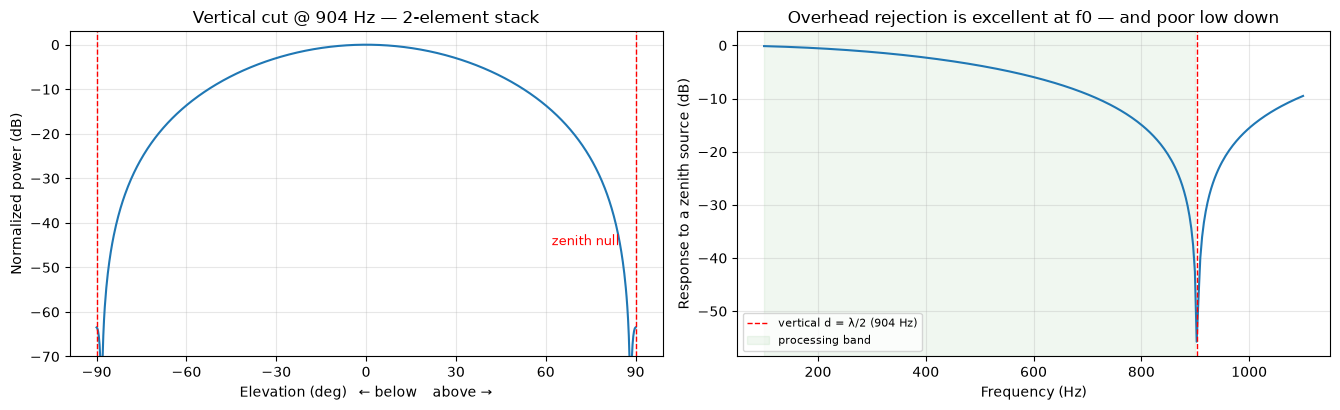

Vertical HPBW @ 904 Hz : 59.8°
Up/down asymmetry        : 3.55e-15 dB  -> still up/down ambiguous, like the ring

Response to a source directly overhead:
   200 Hz :    -0.5 dB
   300 Hz :    -1.2 dB
   500 Hz :    -3.8 dB
   700 Hz :    -9.2 dB
   850 Hz :   -20.6 dB
   904 Hz :   -63.5 dB

For comparison, the 9-element ring leaks an overhead source into EVERY beam at
-1.4 dB at 300 Hz and -4.2 dB at 500 Hz. This panel is far better at the top of its
band (-63 dB at f0) but no better at the bottom -- the null is a narrowband
effect tied to the vertical spacing, not a broadband property of the geometry.


In [6]:
zen_db = []
f_sweep = np.linspace(BAND[0], 1100.0, 300)
for f_ in f_sweep:
    w = das_weights(0.0, STEER_AZ, f_)
    zen_db.append(20 * np.log10(abs(beamformer_output(w, steering_vector(90.0, 0.0, f_))) + 1e-18))
zen_db = np.array(zen_db)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax = axes[0]
ax.plot(el_grid, pdb_el)
ax.axvline(90, color='r', ls='--', lw=1); ax.axvline(-90, color='r', ls='--', lw=1)
ax.annotate('zenith null', (62, -45), fontsize=9, color='r')
ax.set_xticks(range(-90, 91, 30)); ax.set_ylim(-70, 3)
ax.set_xlabel('Elevation (deg)   ← below    above →'); ax.set_ylabel('Normalized power (dB)')
ax.set_title(f'Vertical cut @ {F0:.0f} Hz — 2-element stack')
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(f_sweep, zen_db)
ax.axvline(F_ALIAS, color='r', ls='--', lw=1, label=f'vertical d = λ/2 ({F_ALIAS:.0f} Hz)')
ax.axvspan(*BAND, color='green', alpha=0.06, label='processing band')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Response to a zenith source (dB)')
ax.set_title('Overhead rejection is excellent at f0 — and poor low down')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Vertical HPBW @ {F0:.0f} Hz : {m_el['hpbw']:.1f}°")
asym = float(np.max(np.abs(pdb_el - pdb_el[::-1])))
print(f"Up/down asymmetry        : {asym:.2e} dB  -> still up/down ambiguous, like the ring")
assert asym < 1e-9, "Regression: a 2-element stack steered at el = 0 stays up/down symmetric"

print(f"\nResponse to a source directly overhead:")
for f_ in [200, 300, 500, 700, 850, 904]:
    w = das_weights(0.0, STEER_AZ, f_)
    v = 20 * np.log10(abs(beamformer_output(w, steering_vector(90.0, 0.0, f_))) + 1e-18)
    print(f"  {f_:>4} Hz : {v:7.1f} dB")
zen_f0 = 20*np.log10(abs(beamformer_output(das_weights(0.0, STEER_AZ, F0),
                                           steering_vector(90.0, 0.0, F0))) + 1e-18)
assert zen_f0 < -40, "Regression: the zenith should be deeply nulled at f0"

print(f"\nFor comparison, the 9-element ring leaks an overhead source into EVERY beam at")
print(f"-1.4 dB at 300 Hz and -4.2 dB at 500 Hz. This panel is far better at the top of its")
print(f"band ({zen_f0:.0f} dB at f0) but no better at the bottom -- the null is a narrowband")
print(f"effect tied to the vertical spacing, not a broadband property of the geometry.")


## 7. Rayleigh Resolution — Two Narrowband Sources

*Ideal baseline — supports: band split, resolution requirement.*

> Two sources are *just resolvable* when one's peak falls on the other's first null.

For the long axis that null is at $\sin\theta_{null} = \lambda/(Nd)$, giving **23.6°** at f₀ —
versus **45°** for the ring at its own design frequency. The panel resolves roughly twice as
finely, which is what a 3.32 m aperture buys over a 1.25 m one.

At f = 904 Hz: first null at 23.6°, lambda/D_long = 28.6° (D_long = 3.32 m, lambda = 1.659 m)


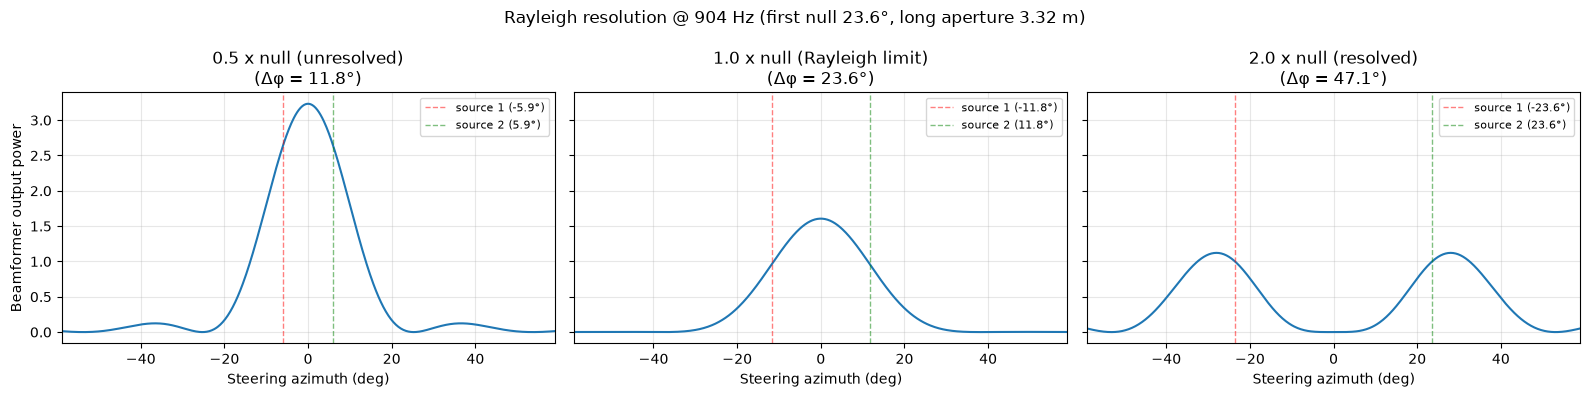

In [7]:
from ura2x5.beamform import two_source_response as _two_source_response
two_source_response = partial(_two_source_response, phi_grid=PHI_GRID, positions=pos, c=C_WATER)

th_null = float(theta_null_line_deg(F0))
print(f"At f = {F0:.0f} Hz: first null at {th_null:.1f}°, "
      f"lambda/D_long = {np.degrees(C_WATER/F0/AP_LONG):.1f}° "
      f"(D_long = {AP_LONG:.2f} m, lambda = {C_WATER/F0:.3f} m)")

separations = {
    '0.5 x null (unresolved)': 0.5 * th_null,
    '1.0 x null (Rayleigh limit)': 1.0 * th_null,
    '2.0 x null (resolved)': 2.0 * th_null,
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (label, dphi) in zip(axes, separations.items()):
    phi1, phi2 = STEER_AZ - dphi/2, STEER_AZ + dphi/2
    g, pw = two_source_response(0.0, phi1, phi2, F0)
    ax.plot(g, pw)
    ax.axvline(phi1, color='r', ls='--', alpha=0.5, lw=1, label=f'source 1 ({phi1:.1f}°)')
    ax.axvline(phi2, color='g', ls='--', alpha=0.5, lw=1, label=f'source 2 ({phi2:.1f}°)')
    ax.set_title(f'{label}\n(Δφ = {dphi:.1f}°)')
    ax.set_xlabel('Steering azimuth (deg)')
    ax.set_xlim(STEER_AZ - 2.5*th_null, STEER_AZ + 2.5*th_null)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('Beamformer output power')
plt.suptitle(f'Rayleigh resolution @ {F0:.0f} Hz (first null {th_null:.1f}°, '
             f'long aperture {AP_LONG:.2f} m)')
plt.tight_layout(); plt.show()


## 8. Resolution vs Frequency

*Ideal baseline — supports: band split.*

Unlike the ring — whose first null simply **ceases to exist** below 459 Hz — a line aperture
always has a null, as long as $\lambda/(Nd) \le 1$. For this panel that holds down to
$c/(Nd) = 361$ Hz. Below that the aperture is shorter than a wavelength and the array stops
discriminating azimuth at all.

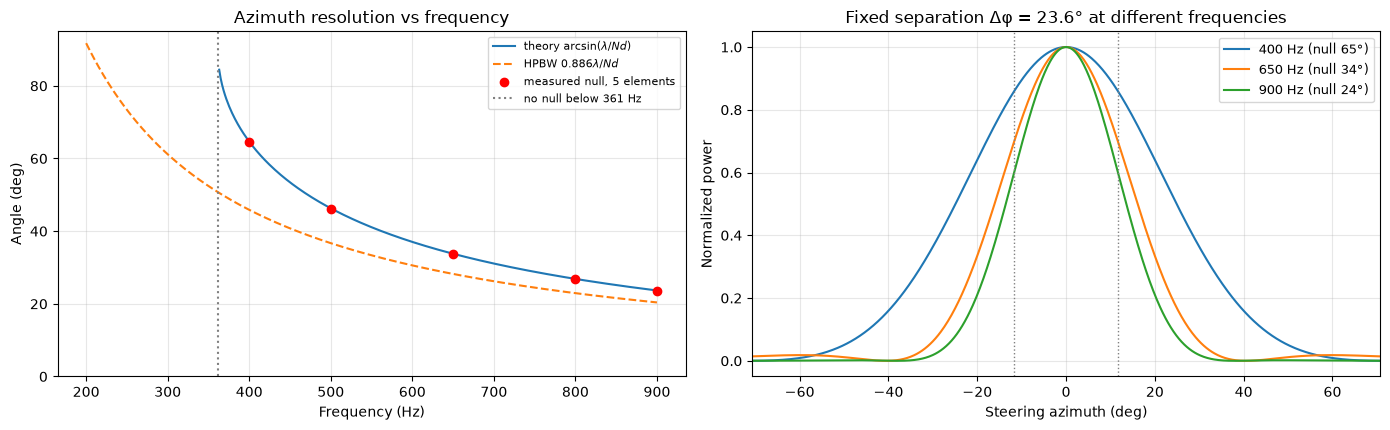

Measured vs theory:
   300 Hz: measured ±  nan°, theory ±  nan°
   400 Hz: measured ± 64.6°, theory ± 64.6°
   500 Hz: measured ± 46.2°, theory ± 46.3°
   650 Hz: measured ± 33.8°, theory ± 33.8°
   800 Hz: measured ± 26.8°, theory ± 26.9°
   900 Hz: measured ± 23.6°, theory ± 23.7°

Below 361 Hz the long aperture is shorter than a wavelength and no null
exists. The ring's equivalent cutoff was 459 Hz, so both arrays lose azimuth
discrimination in the lower part of a 100 Hz-up processing band.


In [8]:
f_cont = np.linspace(200, 900, 400)
f_meas = np.array([300, 400, 500, 650, 800, 900])
meas = [fwd_metrics(to_db_norm(beam_pattern(0, STEER_AZ, f_)), STEER_AZ)['null_half']
        for f_ in f_meas]
f_no_null = C_WATER / (N_LONG * D_ELEM)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
ax = axes[0]
ax.plot(f_cont, theta_null_line_deg(f_cont), label=r'theory $\arcsin(\lambda/Nd)$')
ax.plot(f_cont, hpbw_line_deg(f_cont), ls='--', label=r'HPBW $0.886\lambda/Nd$')
ax.scatter(f_meas, meas, color='r', zorder=5, label='measured null, 5 elements')
ax.axvline(f_no_null, color='gray', ls=':', label=f'no null below {f_no_null:.0f} Hz')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Angle (deg)')
ax.set_title('Azimuth resolution vs frequency'); ax.set_ylim(0, 95)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
fixed = th_null
for f_ in [400, 650, 900]:
    g, pw = two_source_response(0.0, STEER_AZ - fixed/2, STEER_AZ + fixed/2, f_)
    tn = float(theta_null_line_deg(f_))
    ax.plot(g, pw/pw.max(), label=f'{f_} Hz (null {tn:.0f}°)')
ax.axvline(STEER_AZ - fixed/2, color='gray', ls=':', lw=1)
ax.axvline(STEER_AZ + fixed/2, color='gray', ls=':', lw=1)
ax.set_xlim(STEER_AZ - 3*fixed, STEER_AZ + 3*fixed)
ax.set_xlabel('Steering azimuth (deg)'); ax.set_ylabel('Normalized power')
ax.set_title(f'Fixed separation Δφ = {fixed:.1f}° at different frequencies')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Measured vs theory:")
for f_, th in zip(f_meas, meas):
    print(f"  {f_:>4} Hz: measured ±{th:5.1f}°, theory ±{float(theta_null_line_deg(f_)):5.1f}°")
print(f"\nBelow {f_no_null:.0f} Hz the long aperture is shorter than a wavelength and no null")
print("exists. The ring's equivalent cutoff was 459 Hz, so both arrays lose azimuth")
print("discrimination in the lower part of a 100 Hz-up processing band.")


## 9. The Broadband Phase-Mismatch Problem

*Ideal baseline — supports: processing architecture.*

A phase shift equal to $2\pi f_0\tau_n$ is the right correction for delay $\tau_n$ **only** at
$f_0$. Across a broadband signal the weights are wrong by $2\pi(f-f_0)\tau_n$ and coherent
gain falls away from the design frequency.

At broadside this effect vanishes — every $\tau_n$ is zero, so there is nothing to get wrong.
The sweep below therefore steers **off broadside**, which is where the problem actually
bites and where any real system operates.

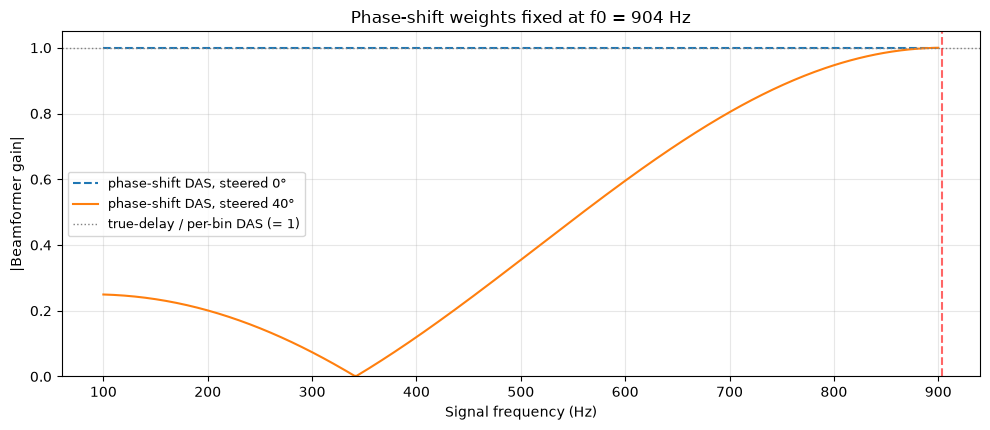

Gain toward the look direction, weights fixed at 904 Hz:
 f (Hz) |  broadside |  steered 40°
    200 |      0.00 dB |      -13.94 dB
    400 |      0.00 dB |      -18.42 dB
    600 |      0.00 dB |       -4.50 dB
    800 |      0.00 dB |       -0.47 dB
    900 |      0.00 dB |       -0.00 dB

At broadside the phase-shift beamformer is exact at every frequency, because every
required delay is zero. Off broadside it degrades just as it does on any array --
so broadband work needs per-FFT-bin steering vectors (sections 11 and 17).


In [9]:
from ura2x5.beamform import das_gain_vs_frequency as _das_gain_vs_frequency
das_gain_vs_frequency = partial(_das_gain_vs_frequency, positions=pos, c=C_WATER)

f_design   = F0
freq_range = np.linspace(BAND[0], BAND[1], 400)
STEER_OFF  = 40.0                         # off broadside: where phase-shift weights matter

fig, ax = plt.subplots(figsize=(10, 4.4))
for steer, style in [(0.0, '--'), (STEER_OFF, '-')]:
    g = das_gain_vs_frequency(STEER_EL, steer, f_design, freq_range)
    ax.plot(freq_range, g, style, label=f'phase-shift DAS, steered {steer:.0f}°')
ax.axhline(1.0, color='gray', ls=':', lw=1, label='true-delay / per-bin DAS (= 1)')
ax.axvline(f_design, color='r', ls='--', alpha=0.6)
ax.set_xlabel('Signal frequency (Hz)'); ax.set_ylabel('|Beamformer gain|')
ax.set_title(f'Phase-shift weights fixed at f0 = {f_design:.0f} Hz')
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Gain toward the look direction, weights fixed at {f_design:.0f} Hz:")
print(f"{'f (Hz)':>7} | {'broadside':>10} | {'steered ' + str(int(STEER_OFF)) + '°':>12}")
for f_ in [200, 400, 600, 800, 900]:
    g0 = das_gain_vs_frequency(STEER_EL, 0.0, f_design, [f_])[0]
    g1 = das_gain_vs_frequency(STEER_EL, STEER_OFF, f_design, [f_])[0]
    print(f"{f_:>7} | {20*np.log10(g0):9.2f} dB | {20*np.log10(g1):11.2f} dB")
print("\nAt broadside the phase-shift beamformer is exact at every frequency, because every")
print("required delay is zero. Off broadside it degrades just as it does on any array --")
print("so broadband work needs per-FFT-bin steering vectors (sections 11 and 17).")


## 10. MVDR Beamformer

*Ideal baseline — supports: interference rejection.*

MVDR minimises output power subject to unit gain toward the look direction:

$$\mathbf{w}_{MVDR} = \frac{\mathbf{R}^{-1}\mathbf{a}}{\mathbf{a}^H\mathbf{R}^{-1}\mathbf{a}}$$

Two cautions specific to this array. MVDR **cannot** null an interferer at the mirror
azimuth, because the mirror steering vector is identical to the target's (§5) — attempting it
would violate the distortionless constraint. And any null MVDR does place is **mirrored
automatically**, so a null on an interferer ahead also suppresses the matching bearing astern.
With the back baffle fitted that second point is largely moot, since little arrives from
astern to begin with; without it, the mirrored null would be a real liability.

The demo below places the interferer at a genuinely different bearing.

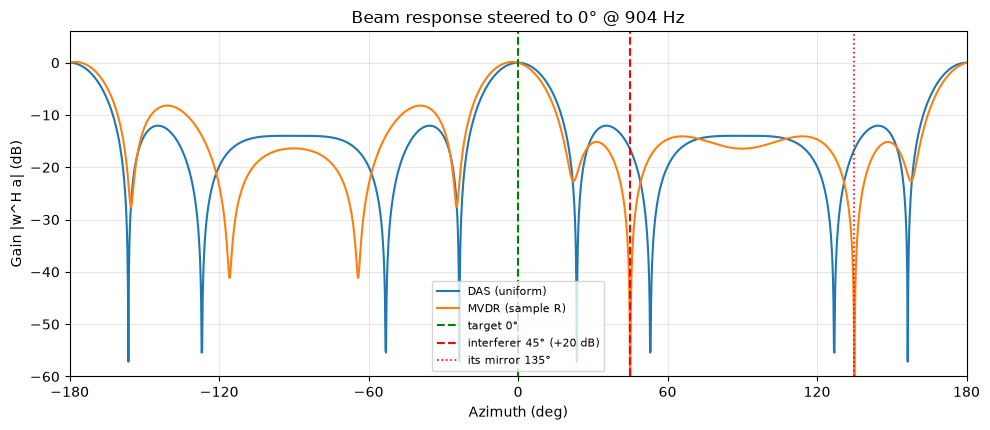

MVDR self-test: |w^H a| at look direction = 1.0000 (expect 1.0)
Gain toward interferer: DAS -16.6 dB, MVDR -64.0 dB
Output SINR: DAS -3.6 dB, MVDR 9.6 dB

The null MVDR places at 45 deg is mirrored automatically at 135 deg --
the array cannot null one without the other. With the back baffle fitted this costs
little, because a target at the mirror bearing is already attenuated by the baffle and
was never going to be worked anyway. On an UNBAFFLED panel it would be a real
liability: a wanted contact astern suppressed as collateral damage.


In [10]:
from ura2x5.beamform import (sample_covariance, load_diag,
                              mvdr_weights as _mvdr_weights,
                              simulate_snapshots as _simulate_snapshots,
                              spatial_spectrum as _spatial_spectrum)
mvdr_weights       = partial(_mvdr_weights, positions=pos, c=C_WATER)
simulate_snapshots = partial(_simulate_snapshots, positions=pos, c=C_WATER)
spatial_spectrum   = partial(_spatial_spectrum, positions=pos, c=C_WATER)

rng = np.random.default_rng(1)
tgt, intf = (0.0, STEER_AZ, 0.0), (0.0, 45.0, 20.0)
Xs = simulate_snapshots([tgt, intf], F0, 200, rng)
R_hat = sample_covariance(Xs)

w_das  = das_weights(0.0, STEER_AZ, F0)
w_mvdr = mvdr_weights(0.0, STEER_AZ, F0, R_hat)
A_grid = steering_vector(0.0, PHI_GRID, F0)
a_i, a_t = steering_vector(0.0, intf[1], F0), steering_vector(0.0, tgt[1], F0)
R_in = 10**(intf[2]/10) * np.outer(a_i, a_i.conj()) + np.eye(N)
sinr = lambda w: 10*np.log10(abs(np.conj(w) @ a_t)**2 * 10**(tgt[2]/10)
                             / np.real(np.conj(w) @ R_in @ w))

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(PHI_GRID, 20*np.log10(np.abs(np.conj(w_das) @ A_grid) + 1e-9), label='DAS (uniform)')
ax.plot(PHI_GRID, 20*np.log10(np.abs(np.conj(w_mvdr) @ A_grid) + 1e-9), label='MVDR (sample R)')
ax.axvline(tgt[1], color='g', ls='--', label=f'target {tgt[1]:.0f}°')
ax.axvline(intf[1], color='r', ls='--', label=f'interferer {intf[1]:.0f}° (+{intf[2]:.0f} dB)')
ax.axvline(float(mirror_azimuth_deg(intf[1])), color='r', ls=':', lw=1.2,
           label=f'its mirror {float(mirror_azimuth_deg(intf[1])):.0f}°')
ax.set_ylim(-60, 6); ax.set_xlim(-180, 180); ax.set_xticks(range(-180, 181, 60))
ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('Gain |w^H a| (dB)')
ax.set_title(f'Beam response steered to {STEER_AZ:.0f}° @ {F0:.0f} Hz')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

mvdr_look = abs(np.conj(w_mvdr) @ a_t)
print(f"MVDR self-test: |w^H a| at look direction = {mvdr_look:.4f} (expect 1.0)")
assert abs(mvdr_look - 1.0) < 1e-6, "Regression: MVDR must hold unit gain toward the look direction"
print(f"Gain toward interferer: DAS {20*np.log10(abs(np.conj(w_das) @ a_i)):.1f} dB, "
      f"MVDR {20*np.log10(abs(np.conj(w_mvdr) @ a_i)):.1f} dB")
print(f"Output SINR: DAS {sinr(w_das):.1f} dB, MVDR {sinr(w_mvdr):.1f} dB")
print(f"\nThe null MVDR places at {intf[1]:.0f} deg is mirrored automatically at "
      f"{float(mirror_azimuth_deg(intf[1])):.0f} deg --")
print("the array cannot null one without the other. With the back baffle fitted this costs")
print("little, because a target at the mirror bearing is already attenuated by the baffle and")
print("was never going to be worked anyway. On an UNBAFFLED panel it would be a real")
print("liability: a wanted contact astern suppressed as collateral damage.")


## 11. DAS vs MVDR — Broadband Comparison

*Ideal baseline — supports: processing architecture.*

**Left:** the gain-vs-frequency test from §9 with the per-bin processors added. Both
true-delay DAS and MVDR recompute $\mathbf{a}(f)$ per bin, so both hold unit gain by
construction.

**Right:** a broadband two-source test over 300–900 Hz, scanned power summed incoherently
across bins.

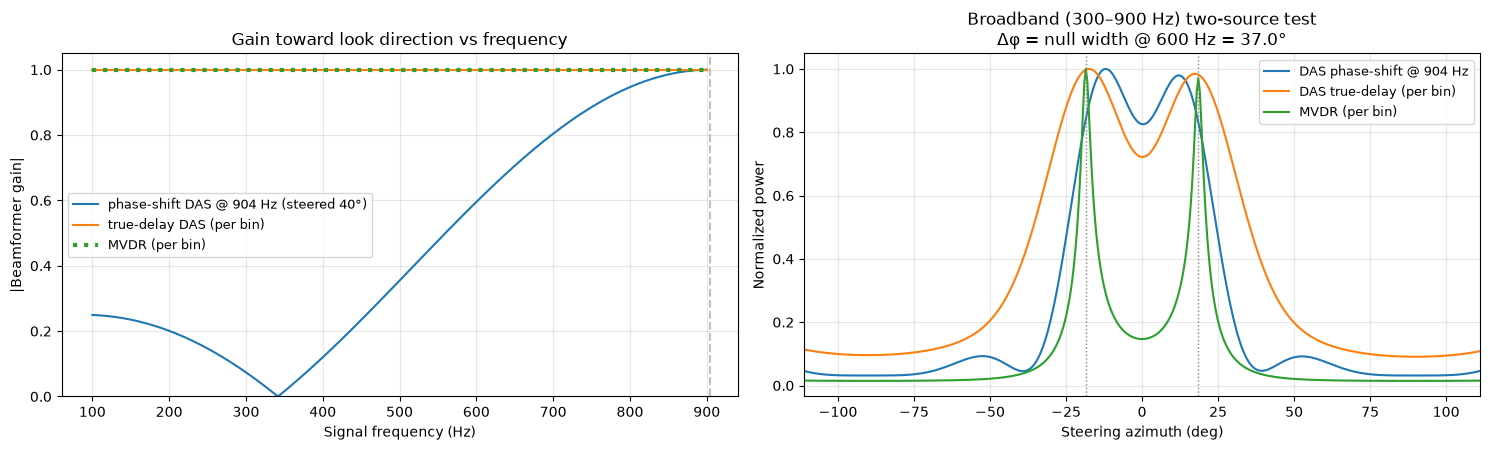

In [11]:
freq_bb = np.linspace(300, BAND[1], 21)
f_center = freq_bb.mean()


def broadband_two_source(phi1, phi2, freq_band, n_snap=64, snr_db=10.0, seed=0,
                          phi_grid=np.arange(-180.0, 180.0, 0.5)):
    rng = np.random.default_rng(seed)
    out = {'das_ps': 0.0, 'das_td': 0.0, 'mvdr': 0.0}
    for f_ in freq_band:
        R = sample_covariance(simulate_snapshots(
            [(0.0, phi1, snr_db), (0.0, phi2, snr_db)], f_, n_snap, rng))
        out['das_ps'] = out['das_ps'] + spatial_spectrum('das_ps', R, f_, 0.0, phi_grid, f_fixed=F0)
        out['das_td'] = out['das_td'] + spatial_spectrum('das_td', R, f_, 0.0, phi_grid)
        out['mvdr']   = out['mvdr']   + spatial_spectrum('mvdr',   R, f_, 0.0, phi_grid)
    return phi_grid, out


fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
g_ps = das_gain_vs_frequency(STEER_EL, STEER_OFF, F0, freq_range)
ax.plot(freq_range, g_ps, label=f'phase-shift DAS @ {F0:.0f} Hz (steered {STEER_OFF:.0f}°)')
ax.plot(freq_range, np.ones_like(freq_range), label='true-delay DAS (per bin)')
ax.plot(freq_range, np.ones_like(freq_range), ':', lw=3, label='MVDR (per bin)')
ax.axvline(F0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Signal frequency (Hz)'); ax.set_ylabel('|Beamformer gain|')
ax.set_title('Gain toward look direction vs frequency'); ax.set_ylim(0, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

dphi = float(theta_null_line_deg(f_center))
phi1, phi2 = STEER_AZ - dphi/2, STEER_AZ + dphi/2
g, spec = broadband_two_source(phi1, phi2, freq_bb)
labels_m = {'das_ps': f'DAS phase-shift @ {F0:.0f} Hz', 'das_td': 'DAS true-delay (per bin)',
            'mvdr': 'MVDR (per bin)'}
ax = axes[1]
for k, P in spec.items():
    ax.plot(g, P / P.max(), label=labels_m[k])
ax.axvline(phi1, color='gray', ls=':', lw=1); ax.axvline(phi2, color='gray', ls=':', lw=1)
ax.set_xlim(STEER_AZ - 3*dphi, STEER_AZ + 3*dphi)
ax.set_xlabel('Steering azimuth (deg)'); ax.set_ylabel('Normalized power')
ax.set_title(f'Broadband (300–{BAND[1]:.0f} Hz) two-source test\n'
             f'Δφ = null width @ {f_center:.0f} Hz = {dphi:.1f}°')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 12. Interactive Explorer

*Ideal baseline — supports: teaching and review.*

Adjust frequency, source separation (as a multiple of the first-null width), SNR and method.

> Requires `ipywidgets`. If the sliders don't render:
> `pip install ipywidgets` and restart the kernel.

In [12]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not available -- install with: pip install ipywidgets")


def interactive_resolution(freq_hz=F0, dphi_factor=1.0, snr_db=10.0, steer_az=0.0, method='das'):
    tn = float(theta_null_line_deg(freq_hz, steer_deg=steer_az))
    if not np.isfinite(tn):
        tn = 60.0
    dphi = dphi_factor * tn
    phi1, phi2 = steer_az - dphi/2, steer_az + dphi/2
    rng_i = np.random.default_rng(42)
    R = sample_covariance(simulate_snapshots([(0, phi1, snr_db), (0, phi2, snr_db)],
                                             freq_hz, 64, rng_i))
    P = spatial_spectrum('das_td' if method == 'das' else 'mvdr', R, freq_hz,
                         phi_grid=PHI_GRID)
    fig, ax = plt.subplots(figsize=(10, 4.4))
    ax.plot(PHI_GRID, 10*np.log10(P / P.max()))
    ax.axvline(phi1, color='r', ls='--', alpha=0.6, label=f'source 1 ({phi1:.1f}°)')
    ax.axvline(phi2, color='g', ls='--', alpha=0.6, label=f'source 2 ({phi2:.1f}°)')
    ax.axvspan(-90, 90, color='green', alpha=0.05)
    ax.set_xlim(-180, 180); ax.set_ylim(-30, 1); ax.set_xticks(range(-180, 181, 60))
    ax.set_xlabel('Steering azimuth (deg)'); ax.set_ylabel('Normalized power (dB)')
    ax.set_title(f'{method.upper()} @ {freq_hz:.0f} Hz | steer {steer_az:.0f}° | '
                 f'Δφ = {dphi_factor:.2f} x null = {dphi:.1f}° | SNR {snr_db:.0f} dB')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


if HAVE_WIDGETS:
    widgets.interact(
        interactive_resolution,
        freq_hz=widgets.FloatSlider(value=F0, min=200.0, max=900.0, step=25.0, description='Freq (Hz)'),
        dphi_factor=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description='Δφ / null'),
        snr_db=widgets.FloatSlider(value=10.0, min=-15.0, max=30.0, step=1.0, description='SNR (dB)'),
        steer_az=widgets.FloatSlider(value=0.0, min=-60.0, max=60.0, step=5.0, description='Steer (°)'),
        method=widgets.Dropdown(options=['das', 'mvdr'], value='das', description='Method'),
    )
else:
    interactive_resolution()


interactive(children=(FloatSlider(value=900.0, description='Freq (Hz)', max=900.0, min=200.0, step=25.0), Floa…

## 13. Amplitude Taper — On a URA It Works

*Ideal baseline — supports: design decision (taper IS worth using here).*

**This is the clearest behavioural difference from the ring.**

On the ring, the "aperture edge" depends on look direction, the sidelobes come from the
$J_0$ shape of the whole circle rather than from truncation, and across-track tapers made
the pattern measurably **worse** — peak sidelobe rose from −7.9 dB to about −3.7 dB.

A URA has **fixed physical edges**. A window applied along the long axis is exactly the
textbook situation: sidelobes fall, the main lobe widens, and some white-noise gain is traded
away. The taper is **separable** — elements sharing a Y coordinate get the same weight.

Taper efficiency $(\sum g)^2/(N\sum g^2)$ is the white-noise array gain given up.

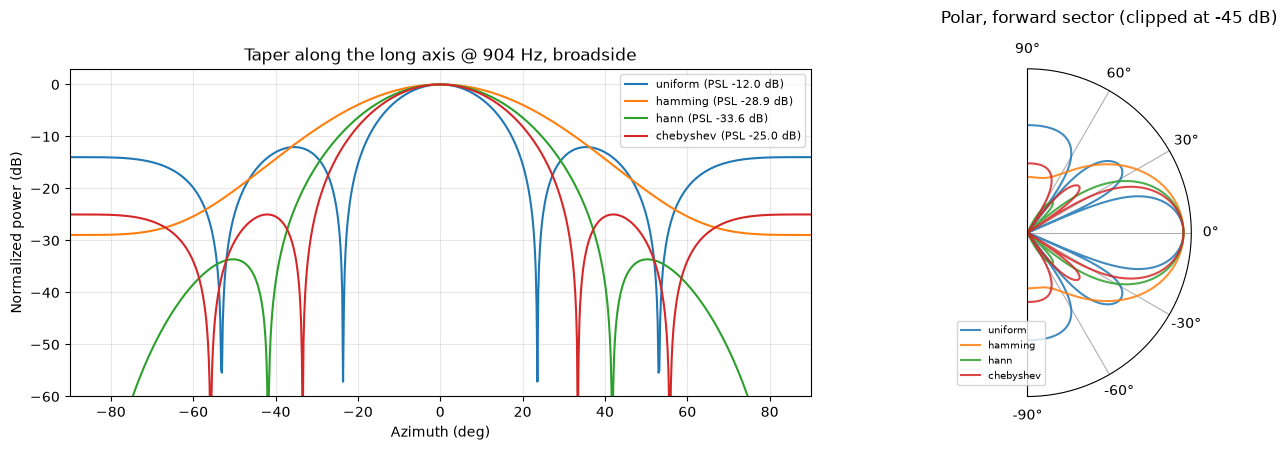

Taper        |    HPBW |     Peak SL |    Efficiency | weights (unique)
------------------------------------------------------------------------------
uniform      |   20.6° |    -12.0 dB |      +0.00 dB | [1.]
hamming      |   35.0° |    -28.9 dB |      -2.02 dB | [0.08 0.54 1.  ]
hann         |   27.8° |    -33.6 dB |      -0.97 dB | [0.25 0.75 1.  ]
chebyshev    |   25.0° |    -25.0 dB |      -0.53 dB | [0.393 0.797 1.   ]

hamming     : PSL -16.9 dB, HPBW +14.4°, gain -2.02 dB vs uniform
hann        : PSL -21.6 dB, HPBW +7.2°, gain -0.97 dB vs uniform
chebyshev   : PSL -13.0 dB, HPBW +4.4°, gain -0.53 dB vs uniform

Best sidelobes: hann at -33.6 dB, costing -0.97 dB of
white-noise gain and widening the beam from 20.6° to 27.8°.

Contrast with the ring (BEAMFORM_LEN section 11), where the same idea RAISED the
peak sidelobe from -7.9 dB to -3.7 dB. Taper is a real design lever on this panel and
an actively harmful one on a ring.


In [13]:
import warnings
from ura2x5.beamform import make_taper as _make_taper
make_taper = partial(_make_taper, positions=pos, axis=1)   # axis 1 = Y = the long axis

taper_cfgs = ['uniform', 'hamming', 'hann', 'chebyshev']

fig = plt.figure(figsize=(15, 4.6))
ax = fig.add_subplot(121)
axp = fig.add_subplot(122, projection='polar')
results = {}
for tp in taper_cfgs:
    with warnings.catch_warnings():
        # chebwin warns that it is unsuited to SPECTRAL analysis at low attenuation; this is
        # pattern synthesis on a 5-element aperture, which is what the window is for.
        warnings.simplefilter('ignore')
        g_amp = make_taper(tp)
    pdb = to_db_norm(beam_pattern(STEER_EL, STEER_AZ, F0, amp=g_amp))
    m = fwd_metrics(pdb, STEER_AZ)
    eff = 10*np.log10(g_amp.sum()**2 / (len(g_amp) * np.sum(g_amp**2)))
    results[tp] = (m['hpbw'], m['psl'], eff, np.unique(np.round(g_amp, 3)))
    ax.plot(PHI_GRID, pdb, label=f'{tp} (PSL {m["psl"]:.1f} dB)')
    axp.plot(np.radians(PHI_GRID), np.clip(pdb, -45, 0) + 45, label=tp, alpha=0.85)

ax.set_xlim(-90, 90); ax.set_ylim(-60, 3)
ax.set_xlabel('Azimuth (deg)'); ax.set_ylabel('Normalized power (dB)')
ax.set_title(f'Taper along the long axis @ {F0:.0f} Hz, broadside')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
axp.set_theta_zero_location('E'); axp.set_yticks([])
# Back-baffled: only the forward half-space exists for this array, so only plot that.
axp.set_thetamin(-90); axp.set_thetamax(90)
axp.set_title('Polar, forward sector (clipped at -45 dB)', pad=14)
axp.legend(fontsize=7, loc='lower left', bbox_to_anchor=(0.02, 0.02))
plt.tight_layout(); plt.show()

print(f'{"Taper":12} | {"HPBW":>7} | {"Peak SL":>11} | {"Efficiency":>13} | weights (unique)')
print('-' * 78)
for tp, (hpbw, psl, eff, w) in results.items():
    print(f'{tp:12} | {hpbw:6.1f}° | {psl:8.1f} dB | {eff:+10.2f} dB | {w}')

u = results['uniform']
print()
for tp, (hpbw, psl, eff, _) in results.items():
    if tp == 'uniform':
        continue
    print(f"{tp:12}: PSL {psl - u[1]:+.1f} dB, HPBW {hpbw - u[0]:+.1f}°, gain {eff:+.2f} dB vs uniform")

best = min(results.items(), key=lambda kv: kv[1][1])
print(f"\nBest sidelobes: {best[0]} at {best[1][1]:.1f} dB, costing {best[1][2]:+.2f} dB of")
print(f"white-noise gain and widening the beam from {u[0]:.1f}° to {best[1][0]:.1f}°.")
print("\nContrast with the ring (BEAMFORM_LEN section 11), where the same idea RAISED the")
print("peak sidelobe from -7.9 dB to -3.7 dB. Taper is a real design lever on this panel and")
print("an actively harmful one on a ring.")
assert results['hamming'][1] < results['uniform'][1] - 10, \
    "Regression: on a URA a Hamming taper must LOWER the peak sidelobe substantially"


## 14. Steering — Broadening, and the Usable Sector

*Ideal baseline — supports: coverage requirement; drives the multi-panel decision.*

**The second big difference from the ring.** A ring has no broadside: steering it merely
rotates an identical pattern, so its coverage is a full 360° at constant performance.

A planar array does have a broadside, and its effective aperture shrinks as
$\cos\phi_s$. The beam therefore broadens as

$$\mathrm{HPBW}(\phi_s) \approx \frac{0.886\,\lambda}{Nd\cos\phi_s}$$

and near endfire the pattern degenerates entirely: azimuth maps onto $\sin\phi$, which
compresses to nothing as $\phi \to 90°$.

The sweep below measures where that becomes unacceptable.

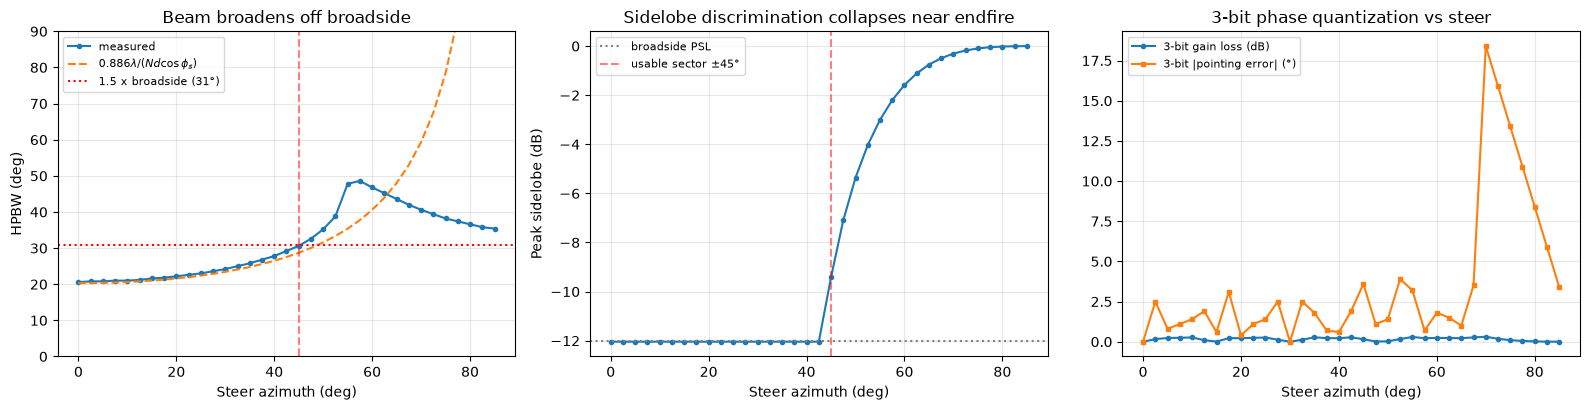

Broadside HPBW 20.6°.
 steer |    HPBW | x broadside |      PSL
    0° |   20.6° |       1.00x |   -12.0 dB
   10° |   21.0° |       1.02x |   -12.0 dB
   20° |   22.2° |       1.08x |   -12.0 dB
   30° |   24.2° |       1.17x |   -12.0 dB
   40° |   27.8° |       1.35x |   -12.0 dB
   50° |   35.2° |       1.71x |    -5.4 dB
   60° |   46.8° |       2.27x |    -1.6 dB
   70° |   40.6° |       1.97x |    -0.3 dB
   80° |   36.6° |       1.78x |    -0.0 dB

Usable sector (HPBW within 1.5x broadside): about ±45°.
Beyond it the beam widens fast and the sidelobe floor rises toward 0 dB, because
azimuth maps onto sin(phi), which stops changing as phi approaches 90°.

Coverage consequence: one panel covers roughly 90° of the 360° horizon
at full performance, and only one of the two sides (section 5). Full coverage needs
about 4 panels, versus a single ring.


In [14]:
sweep = np.arange(0, 86, 2.5)
res = {'hpbw': [], 'psl': [], 'loss_q': [], 'point_q': []}
for s in sweep:
    pdb = to_db_norm(beam_pattern(0, float(s), F0))
    m = fwd_metrics(pdb, float(s), search=70)
    res['hpbw'].append(m['hpbw']); res['psl'].append(m['psl'])
    wq = das_weights(0, float(s), F0, bits=PHASE_BITS)
    res['loss_q'].append(-20*np.log10(abs(beamformer_output(
        wq, steering_vector(0, float(s), F0)))))
    mq = fwd_metrics(to_db_norm(beam_pattern(0, float(s), F0, bits=PHASE_BITS)),
                     float(s), search=70)
    res['point_q'].append(wrap180(mq['peak'] - s))

hp0 = res['hpbw'][0]
ratio = np.array(res['hpbw']) / hp0
ok = np.where(ratio <= 1.5)[0]
SECTOR = float(sweep[ok[-1]]) if len(ok) else 0.0

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax = axes[0]
ax.plot(sweep, res['hpbw'], 'o-', ms=3, label='measured')
ax.plot(sweep, hpbw_line_deg(F0, steer_deg=sweep), '--', label=r'$0.886\lambda/(Nd\cos\phi_s)$')
ax.axhline(1.5*hp0, color='r', ls=':', label=f'1.5 x broadside ({1.5*hp0:.0f}°)')
ax.axvline(SECTOR, color='r', ls='--', alpha=0.5)
ax.set_xlabel('Steer azimuth (deg)'); ax.set_ylabel('HPBW (deg)')
ax.set_title('Beam broadens off broadside'); ax.set_ylim(0, 90)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(sweep, res['psl'], 'o-', ms=3)
ax.axhline(-12.0, color='gray', ls=':', label='broadside PSL')
ax.axvline(SECTOR, color='r', ls='--', alpha=0.5, label=f'usable sector ±{SECTOR:.0f}°')
ax.set_xlabel('Steer azimuth (deg)'); ax.set_ylabel('Peak sidelobe (dB)')
ax.set_title('Sidelobe discrimination collapses near endfire')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(sweep, res['loss_q'], 'o-', ms=3, label=f'{PHASE_BITS}-bit gain loss (dB)')
ax.plot(sweep, np.abs(res['point_q']), 's-', ms=3, label=f'{PHASE_BITS}-bit |pointing error| (°)')
ax.set_xlabel('Steer azimuth (deg)')
ax.set_title(f'{PHASE_BITS}-bit phase quantization vs steer')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Broadside HPBW {hp0:.1f}°.")
print(f"{'steer':>6} | {'HPBW':>7} | {'x broadside':>11} | {'PSL':>8}")
for s, h, p in zip(sweep[::4], res['hpbw'][::4], res['psl'][::4]):
    print(f"{s:5.0f}° | {h:6.1f}° | {h/hp0:10.2f}x | {p:7.1f} dB")
print(f"\nUsable sector (HPBW within 1.5x broadside): about ±{SECTOR:.0f}°.")
print(f"Beyond it the beam widens fast and the sidelobe floor rises toward 0 dB, because")
print(f"azimuth maps onto sin(phi), which stops changing as phi approaches 90°.")
print(f"\nCoverage consequence: one panel covers roughly {2*SECTOR:.0f}° of the {360}° horizon")
print(f"at full performance, and only one of the two sides (section 5). Full coverage needs")
print(f"about {int(np.ceil(360.0/(2*SECTOR)))} panels, versus a single ring.")
assert 35.0 <= SECTOR <= 55.0, "Regression: the usable steering sector should be around +/-45 deg"


## 15. Spatial Aliasing — Two Thresholds, Not One

*Ideal baseline — supports: anti-alias filtering and band selection.*

d = 0.83 m is a **large** spacing — more than twice the ring's 0.4275 m chord — so spatial
sampling is this array's binding constraint. But the usual "d must be ≤ λ/2" statement hides
that there are really two thresholds, because a grating lobe appears when

$$\sin\phi_g = \sin\phi_s \pm \frac{\lambda}{d}, \qquad |\sin\phi_g| \le 1 .$$

| | Frequency | Condition |
|---|---|---|
| **Alias-free at every steering angle** | below **904 Hz** | $d \le \lambda/2$ |
| Alias-free **at broadside only**, with a shrinking steer sector above it | 904 – **1807 Hz** | max steer $\arcsin(\lambda/d - 1)$ |
| Aliased **even at broadside** | above **1807 Hz** | $d \ge \lambda$ |

This is why the processing band stops at 900 Hz: it is the band over which the panel can be
steered anywhere in its sector without growing a false target.

 f (Hz) |  lam/d | max steer | forward peaks > -6 dB at steer 0/20/40/60
------------------------------------------------------------------------------------
('max steer' = largest steer with no grating lobe; 'none' = aliased even at broadside)
    400 |  4.518 |       any | [1, 1, 1, 1]
    700 |  2.582 |       any | [1, 1, 1, 1]
    904 |  1.999 |     87.6° | [1, 1, 1, 1]
   1100 |  1.643 |     40.0° | [1, 1, 1, 2]
   1200 |  1.506 |     30.4° | [1, 1, 2, 2]
   1500 |  1.205 |     11.8° | [1, 2, 2, 2]
   1807 |  1.000 |      0.0° | [1, 2, 2, 2]
   2200 |  0.821 |      none | [3, 2, 2, 3]

The measured peak counts track the analytic limit exactly: an extra peak appears in
the forward sector precisely when the steer angle passes arcsin(lambda/d - 1).


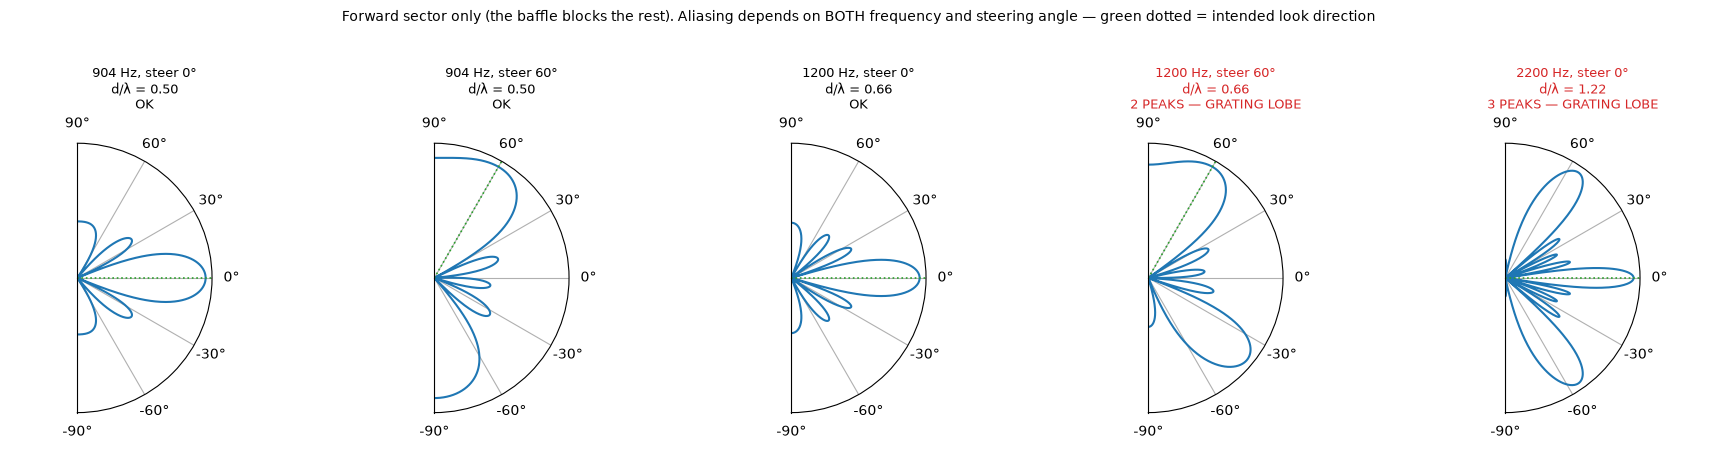


Operationally: keep the anti-alias filter at or below 900 Hz. Energy above
904 Hz reaching the beamformer can create a false contact whenever the beam is
steered off broadside -- and the false contact moves with steer angle, which is a
good way to recognise it.


In [15]:
def fwd_peak_count(pdb, thr=-6.0):
    '''Local maxima above thr within the forward half-space (the mirror lobe is excluded).'''
    p = pdb[FWD]
    pk = (p > np.roll(p, 1)) & (p >= np.roll(p, -1)) & (p > thr)
    return int(pk[1:-1].sum())


def max_steer_before_grating(freq):
    '''arcsin(lambda/d - 1): the largest steer with no grating lobe in visible space.'''
    s = C_WATER / (freq * D_ELEM) - 1.0
    if s >= 1.0:
        return 90.0          # lambda >= 2d: no grating lobe at any steer
    if s <= 0.0:
        return np.nan        # lambda <= d: a grating lobe is visible even at broadside
    return float(np.degrees(np.arcsin(s)))


print(f"{'f (Hz)':>7} | {'lam/d':>6} | {'max steer':>9} | forward peaks > -6 dB at steer 0/20/40/60")
print('-' * 84)
print("('max steer' = largest steer with no grating lobe; 'none' = aliased even at broadside)")
for f_ in [400, 700, 904, 1100, 1200, 1500, 1807, 2200]:
    ms = max_steer_before_grating(f_)
    cnts = [fwd_peak_count(to_db_norm(beam_pattern(0.0, float(s), float(f_))))
            for s in (0, 20, 40, 60)]
    ms_txt = 'none' if not np.isfinite(ms) else (
        'any' if ms >= 89.9 else f'{ms:.1f}°')
    print(f"{f_:>7} | {C_WATER/(f_*D_ELEM):6.3f} | {ms_txt:>9} | {cnts}")

print("\nThe measured peak counts track the analytic limit exactly: an extra peak appears in")
print("the forward sector precisely when the steer angle passes arcsin(lambda/d - 1).")
assert fwd_peak_count(to_db_norm(beam_pattern(0.0, 60.0, F0))) == 1, \
    "Regression: at f0 the panel must stay alias-free even steered 60 deg"
assert fwd_peak_count(to_db_norm(beam_pattern(0.0, 60.0, 1200.0))) > 1, \
    "Regression: at 1200 Hz a 60 deg steer must produce a grating lobe"

test = [(F0, 0.0), (F0, 60.0), (1200.0, 0.0), (1200.0, 60.0), (2200.0, 0.0)]
fig, axes = plt.subplots(1, len(test), figsize=(18, 3.8), subplot_kw={'projection': 'polar'})
for ax, (f_, s_) in zip(axes, test):
    pdb = to_db_norm(beam_pattern(0.0, s_, f_))
    n_pk = fwd_peak_count(pdb)
    ax.plot(np.radians(PHI_GRID), np.clip(pdb, -25, 0) + 25)
    ax.set_theta_zero_location('E'); ax.set_yticks([])
    # Back-baffled: only the forward half-space exists as far as this array is concerned.
    ax.set_thetamin(-90); ax.set_thetamax(90)
    ax.axvline(np.radians(s_), color='tab:green', ls=':', lw=1.2)
    tag = 'OK' if n_pk == 1 else f'{n_pk} PEAKS — GRATING LOBE'
    ax.set_title(f'{f_:.0f} Hz, steer {s_:.0f}°\nd/λ = {D_ELEM*f_/C_WATER:.2f}\n{tag}',
                 fontsize=9, color='k' if n_pk == 1 else 'tab:red')
plt.suptitle('Forward sector only (the baffle blocks the rest). '
             'Aliasing depends on BOTH frequency and steering angle — '
             'green dotted = intended look direction', fontsize=10, y=1.10)
plt.tight_layout(); plt.show()

print(f"\nOperationally: keep the anti-alias filter at or below {BAND[1]:.0f} Hz. Energy above")
print(f"{F_ALIAS:.0f} Hz reaching the beamformer can create a false contact whenever the beam is")
print(f"steered off broadside -- and the false contact moves with steer angle, which is a")
print(f"good way to recognise it.")


### 15.1 The Whole Band at Broadside, 50 Hz → 3 kHz

*Ideal baseline — supports: band selection and the anti-alias filter.*

Steered to broadside and swept across frequency, the panel passes through **four distinct
regimes**. Everything below follows from two numbers already derived — the long aperture
$Nd = 4.15$ m and the element spacing $d = 0.83$ m:

| Regime | Band | Condition | What it looks like |
|---|---|---|---|
| **No discrimination** | below **361 Hz** | $\lambda > Nd$ | aperture shorter than a wavelength; no null exists; nearly omnidirectional across the forward sector |
| **Clean, steerable** | 361 – **904 Hz** | $d \le \lambda/2$ | one main lobe, no grating lobe at *any* steer. **This is the processing band.** |
| **Clean at broadside only** | 904 – **1807 Hz** | $\lambda/2 < d < \lambda$ | still one lobe pointing ahead, but a grating lobe enters as soon as the beam is steered off broadside (§15 table) |
| **Aliased outright** | above **1807 Hz** | $d \ge \lambda$ | grating lobes present *even at broadside* — full-height false targets |

The last three panels (1200, 1500, 3000 Hz) are **outside the 100–900 Hz processing band**.
They are plotted precisely to show what the anti-alias filter is there to keep out: at 3 kHz
the array reports three targets of nearly equal strength when only one exists.

All panels are forward-sector only, since the panel is back-baffled.

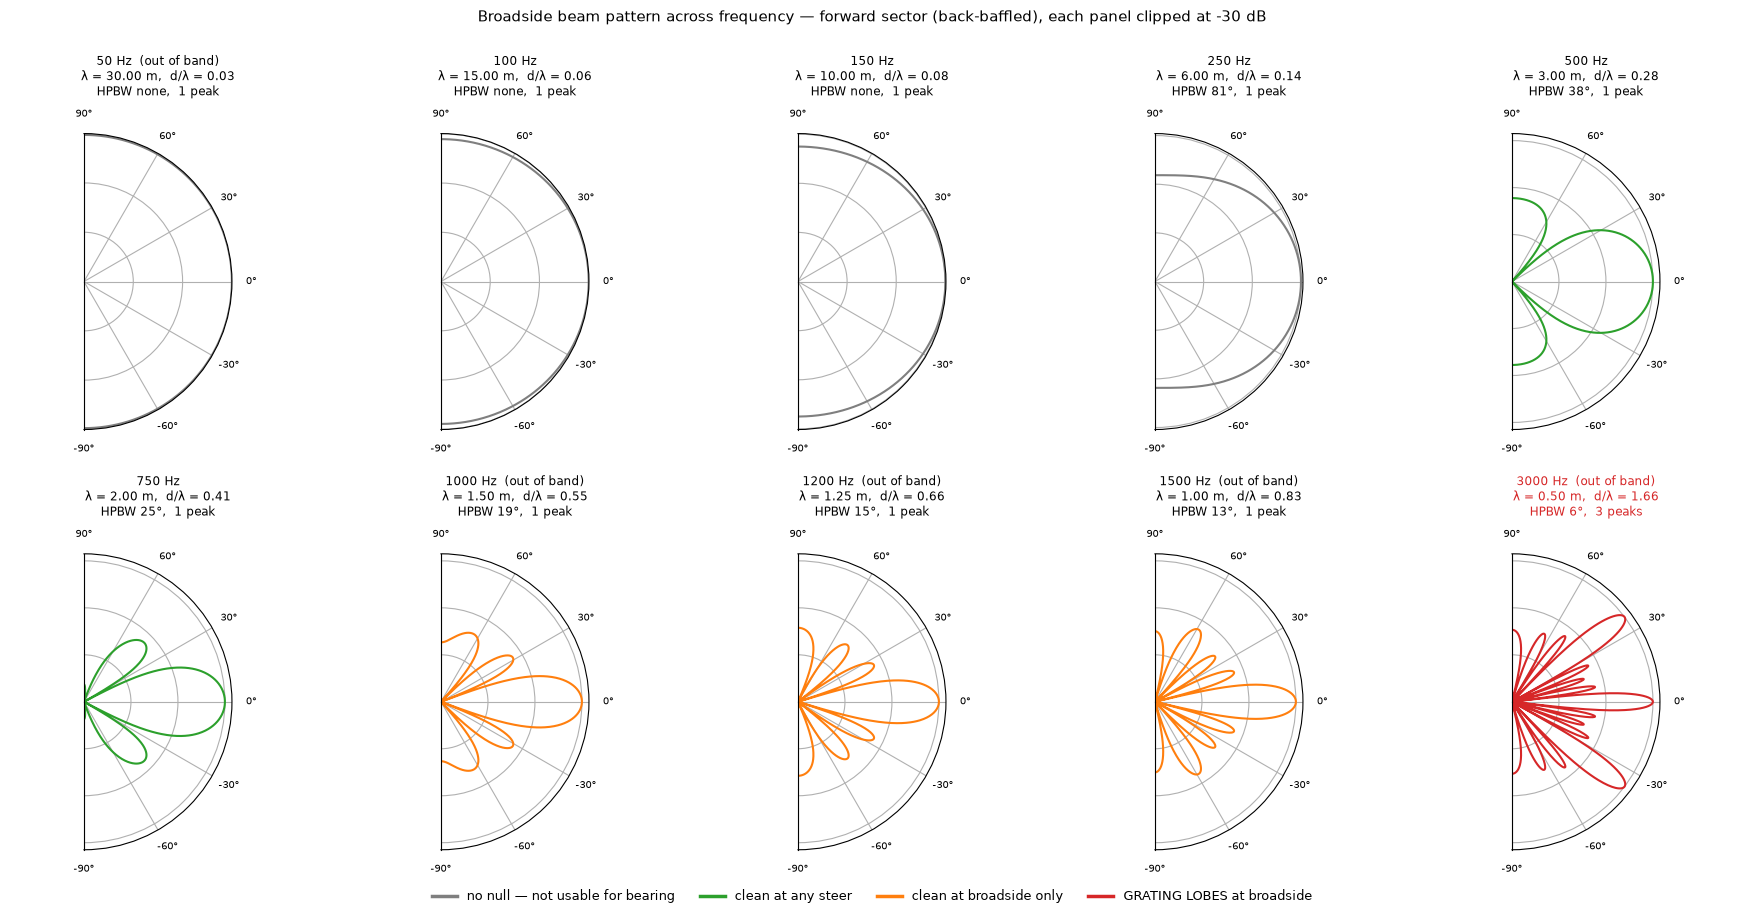

 f (Hz) |   λ (m) |   λ/Nd |   d/λ |    HPBW |    null |      PSL | pks | regime
------------------------------------------------------------------------------------------------------------
     50 |   30.00 |   7.23 |  0.03 |    none |    none |      n/a |   1 | no null — not usable for bearing   [outside 100-900 Hz band]
    100 |   15.00 |   3.61 |  0.06 |    none |    none |      n/a |   1 | no null — not usable for bearing
    150 |   10.00 |   2.41 |  0.08 |    none |    none |      n/a |   1 | no null — not usable for bearing
    250 |    6.00 |   1.45 |  0.14 |   81.0° |    none |      n/a |   1 | no null — not usable for bearing
    500 |    3.00 |   0.72 |  0.28 |   37.8° |   46.2° |   -12.2 dB |   1 | clean at any steer
    750 |    2.00 |   0.48 |  0.41 |   25.0° |   28.8° |   -12.0 dB |   1 | clean at any steer
   1000 |    1.50 |   0.36 |  0.55 |   18.6° |   21.2° |   -12.0 dB |   1 | clean at broadside only   [outside 100-900 Hz band]
   1200 |    1.25 |   0.30 |  0.66 |

In [16]:
sweep_f = [50, 100, 150, 250, 500, 750, 1000, 1200, 1500, 3000]

REGIME = [
    (f_no_null,   'no null — not usable for bearing', 'tab:gray'),
    (F_ALIAS,     'clean at any steer',               'tab:green'),
    (F_ALIAS_BS,  'clean at broadside only',          'tab:orange'),
    (np.inf,      'GRATING LOBES at broadside',       'tab:red'),
]


def regime_of(f_):
    for lim, name, col in REGIME:
        if f_ < lim:
            return name, col
    return REGIME[-1][1], REGIME[-1][2]


fig, axes = plt.subplots(2, 5, figsize=(18, 9.0), subplot_kw={'projection': 'polar'})
rows = []
for ax, f_ in zip(axes.ravel(), sweep_f):
    pdb = to_db_norm(beam_pattern(0.0, 0.0, float(f_)))
    m = fwd_metrics(pdb, 0.0, search=89.0)
    npk = fwd_peak_count(pdb)
    name, col = regime_of(f_)
    in_band = BAND[0] <= f_ <= BAND[1]

    ax.plot(np.radians(PHI_GRID), np.clip(pdb, -30, 0) + 30, color=col)
    ax.set_theta_zero_location('E'); ax.set_thetamin(-90); ax.set_thetamax(90)
    ax.set_yticks([10, 20, 30]); ax.set_yticklabels([])
    ax.set_thetagrids([-90, -60, -30, 0, 30, 60, 90], fontsize=7)
    hp = 'none' if not np.isfinite(m['hpbw']) else f"{m['hpbw']:.0f}°"
    ax.set_title(f"{f_} Hz{'' if in_band else '  (out of band)'}\n"
                 f"λ = {C_WATER/f_:.2f} m,  d/λ = {D_ELEM*f_/C_WATER:.2f}\n"
                 f"HPBW {hp},  {npk} peak{'s' if npk != 1 else ''}",
                 fontsize=8.5, color='k' if npk == 1 else 'tab:red', pad=10)
    rows.append((f_, C_WATER/f_, C_WATER/f_/(N_LONG*D_ELEM), D_ELEM*f_/C_WATER,
                 m['hpbw'], m['null_half'], m['psl'], npk, name, in_band))

handles = [plt.Line2D([], [], color=c, lw=2.5, label=nm) for _, nm, c in REGIME[:3]]
handles.append(plt.Line2D([], [], color='tab:red', lw=2.5, label=REGIME[3][1]))
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
fig.suptitle('Broadside beam pattern across frequency — forward sector (back-baffled), '
             'each panel clipped at -30 dB', fontsize=11, y=0.99)
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
plt.show()

print(f"{'f (Hz)':>7} | {'λ (m)':>7} | {'λ/Nd':>6} | {'d/λ':>5} | {'HPBW':>7} | "
      f"{'null':>7} | {'PSL':>8} | {'pks':>3} | regime")
print('-' * 108)
for f_, lam, lnd, dl, hp, nl_, psl, npk, name, in_band in rows:
    hp_s = '   none' if not np.isfinite(hp) else f"{hp:6.1f}°"
    nl_s = '   none' if not np.isfinite(nl_) else f"{nl_:6.1f}°"
    psl_s = '     n/a' if not np.isfinite(psl) else f"{psl:7.1f} dB"
    flag = '' if in_band else '   [outside 100-900 Hz band]'
    print(f"{f_:>7} | {lam:7.2f} | {lnd:6.2f} | {dl:5.2f} | {hp_s} | {nl_s} | {psl_s} | "
          f"{npk:>3} | {name}{flag}")

print(f"\nThe three thresholds, all pure geometry:")
print(f"  lambda = Nd  -> {f_no_null:6.1f} Hz : below this no null exists at all")
print(f"  d = lambda/2 -> {F_ALIAS:6.1f} Hz : below this, alias-free at ANY steering angle")
print(f"  d = lambda   -> {F_ALIAS_BS:6.1f} Hz : above this, grating lobes even at broadside")
print(f"\nThe usable bearing band is therefore {f_no_null:.0f}-{F_ALIAS:.0f} Hz, which is why the")
print(f"processing band is set to {BAND[0]:.0f}-{BAND[1]:.0f} Hz. Note how little the array does at the")
print(f"bottom end: at 50 Hz the forward sector is essentially one broad lobe, so those bins")
print(f"carry energy for DETECTION but almost no bearing information.")

# Regressions tying the picture to the geometry.
lo = [r for r in rows if r[0] < f_no_null]
assert all(not np.isfinite(r[5]) for r in lo), \
    "Regression: below lambda = Nd there must be no first null"
assert rows[sweep_f.index(3000)][7] > 1, \
    "Regression: 3 kHz must show grating lobes at broadside"
assert all(r[7] == 1 for r in rows if f_no_null <= r[0] <= F_ALIAS_BS), \
    "Regression: between the thresholds broadside must stay single-lobed"
print("\n[OK] The four regimes match the geometry thresholds exactly.")


### 15.2 The Same Sweep with MVDR

*Ideal baseline — supports: whether adaptive beamforming is worth it, and where it is not.*

The same ten frequencies, same broadside look direction — but MVDR instead of DAS.

**MVDR needs something to adapt to.** Against spatially white noise its solution reduces
*exactly* to DAS, so a sweep with no interference would reproduce §15.1 line for line. To make
the comparison mean anything there is a **+20 dB interferer at +40°**, and the question each
panel answers is: *can the array null it, and what does nulling cost?*

The cost is the thing to watch, and it is not visible in the beam pattern. It is the
**white-noise gain**

$$\mathrm{WNG} = \frac{1}{\mathbf{w}^H\mathbf{w}},$$

the array gain against *uncorrelated* per-element noise. Uniform DAS always achieves
WNG = N = 10.0 dB. When MVDR is asked to null an interferer that sits **inside its own
beamwidth** — which is what happens at low frequency, where the beam is 60–90° wide — the only
solution is a **superdirective** one: large, near-cancelling weights that place a deep null at
the price of amplifying uncorrelated noise and becoming hypersensitive to gain, phase and
position errors.

A low WNG is therefore a warning that the pattern shown is **not achievable on real hardware**,
however good it looks. Panels are flagged where WNG falls more than 4 dB below DAS.

The covariance here is the exact one, $\mathbf{R} = \sigma_i^2\mathbf{a}_i\mathbf{a}_i^H +
\mathbf{I}$, with the standard diagonal loading. A real system estimates $\mathbf{R}$ from
snapshots, which adds its own error on top of everything below.

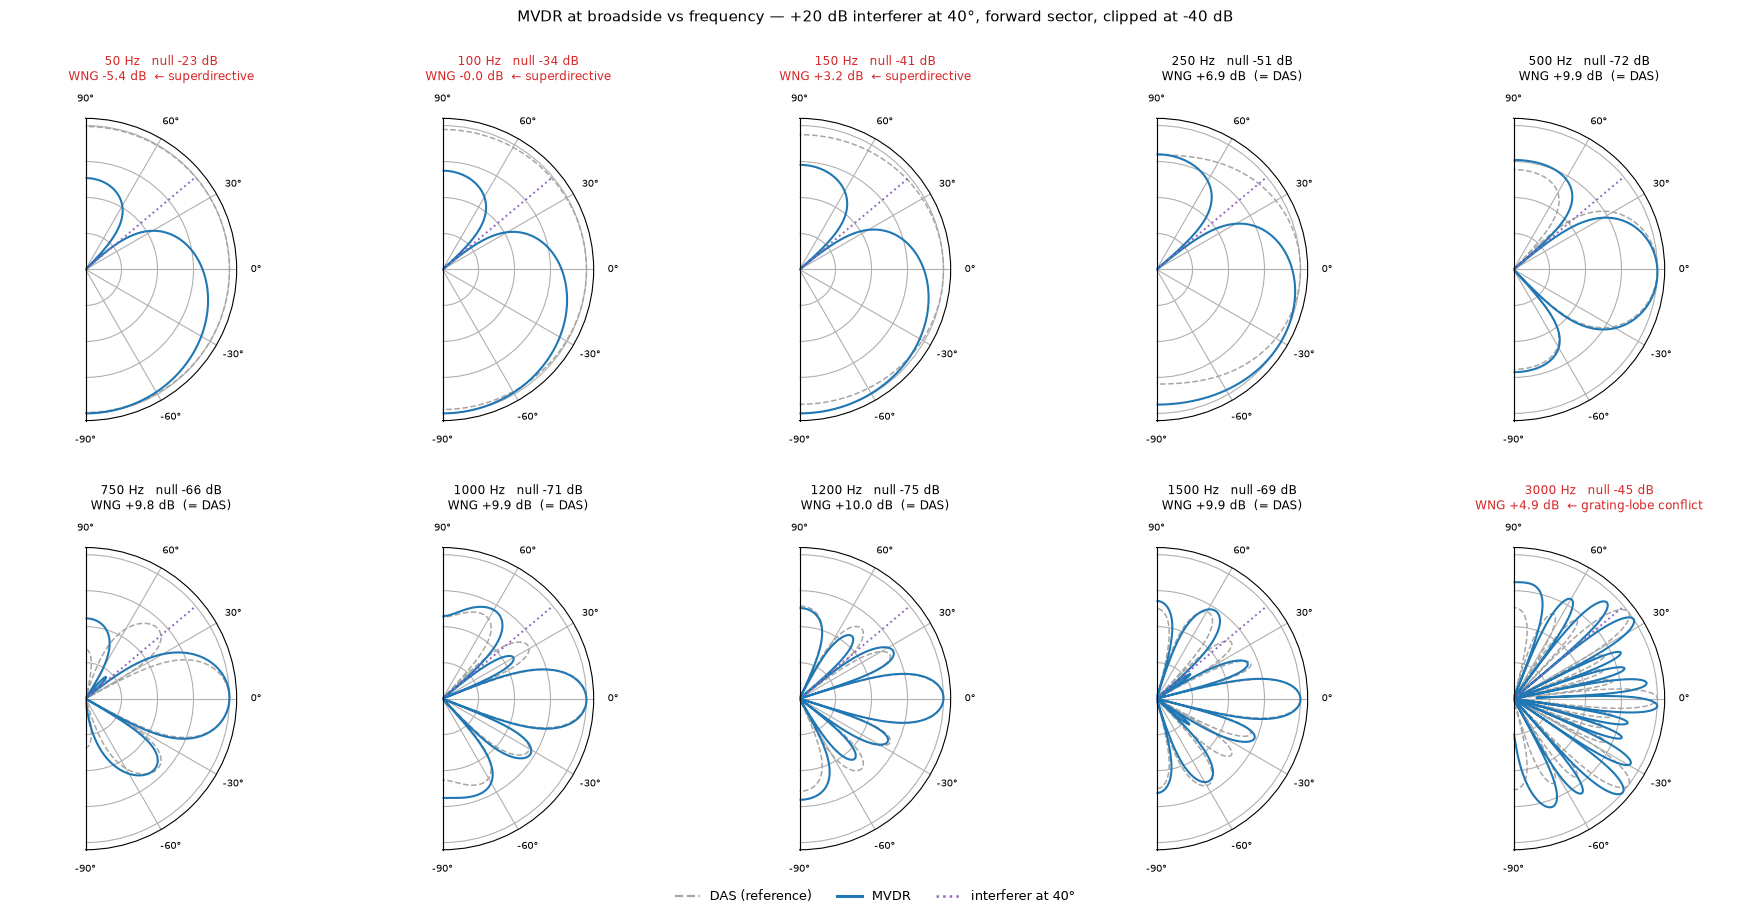

 f (Hz) |    HPBW | null @ intf |      WNG |   vs DAS | verdict
--------------------------------------------------------------------------------------------
     50 |   61.2° |      -22.6 dB |   -5.41 dB |  +15.41 dB | 15 dB WNG penalty — superdirective
    100 |   65.8° |      -34.2 dB |   -0.01 dB |  +10.01 dB | 10 dB WNG penalty — superdirective
    150 |   75.4° |      -41.3 dB |   +3.20 dB |   +6.80 dB | 7 dB WNG penalty — superdirective
    250 |   93.6° |      -50.7 dB |   +6.92 dB |   +3.08 dB | free: MVDR costs nothing
    500 |   36.6° |      -71.6 dB |   +9.93 dB |   +0.07 dB | free: MVDR costs nothing
    750 |   27.4° |      -66.1 dB |   +9.76 dB |   +0.24 dB | free: MVDR costs nothing
   1000 |   19.0° |      -70.7 dB |   +9.91 dB |   +0.09 dB | free: MVDR costs nothing
   1200 |   15.8° |      -75.4 dB |   +9.97 dB |   +0.03 dB | free: MVDR costs nothing
   1500 |   13.0° |      -68.9 dB |   +9.87 dB |   +0.13 dB | free: MVDR costs nothing
   3000 |    6.8° |      -45.4 

In [17]:
from ura2x5.beamform import mvdr_weights as _mvdr_w
mvdr_w = partial(_mvdr_w, positions=pos, c=C_WATER)

INTF_AZ, INTF_INR = 40.0, 20.0        # interferer bearing and interference-to-noise ratio
WNG_DAS = 10 * np.log10(N)            # uniform DAS reference: always 10 log10(N)
WNG_WARN = WNG_DAS - 4.0              # flag anything more than 4 dB below DAS


def mvdr_at(f_, steer_az=0.0, intf_az=INTF_AZ, inr_db=INTF_INR, loading=1e-2):
    '''MVDR weights against one interferer, using the exact covariance.'''
    a_i = steering_vector(0.0, intf_az, f_)
    R = 10 ** (inr_db / 10) * np.outer(a_i, a_i.conj()) + np.eye(N)
    w = mvdr_w(0.0, steer_az, f_, R, loading=loading)
    return w, a_i


fig, axes = plt.subplots(2, 5, figsize=(18, 9.0), subplot_kw={'projection': 'polar'})
rows_m = []
for ax, f_ in zip(axes.ravel(), sweep_f):
    w, a_i = mvdr_at(float(f_))
    A = steering_vector(0.0, PHI_GRID, float(f_))
    pdb_m = to_db_norm(np.abs(np.conj(w) @ A) ** 2)
    pdb_d = to_db_norm(beam_pattern(0.0, 0.0, float(f_)))

    wng = 10 * np.log10(1.0 / np.real(np.conj(w) @ w))
    null_db = 20 * np.log10(abs(beamformer_output(w, a_i)) + 1e-18)
    m = fwd_metrics(pdb_m, 0.0, search=89.0)
    name, _col = regime_of(f_)
    fragile = wng < WNG_WARN
    # Two different causes produce the same WNG symptom, so name them separately.
    cause = ('superdirective' if (fragile and f_ < F_ALIAS) else
             ('grating-lobe conflict' if fragile else ''))

    ax.plot(np.radians(PHI_GRID), np.clip(pdb_d, -40, 0) + 40, '--', color='0.65', lw=1.1,
            label='DAS')
    ax.plot(np.radians(PHI_GRID), np.clip(pdb_m, -40, 0) + 40, color='tab:blue',
            label='MVDR')
    ax.plot([np.radians(INTF_AZ)] * 2, [0, 40], color='tab:purple', ls=':', lw=1.4)
    ax.set_theta_zero_location('E'); ax.set_thetamin(-90); ax.set_thetamax(90)
    ax.set_yticks([10, 20, 30, 40]); ax.set_yticklabels([])
    ax.set_thetagrids([-90, -60, -30, 0, 30, 60, 90], fontsize=7)
    ax.set_title(f"{f_} Hz   null {null_db:.0f} dB\n"
                 f"WNG {wng:+.1f} dB"
                 f"{'  ← ' + cause if fragile else '  (= DAS)'}",
                 fontsize=8.5, color='tab:red' if fragile else 'k', pad=10)
    rows_m.append((f_, m['hpbw'], null_db, wng, WNG_DAS - wng, fragile, cause))

h = [plt.Line2D([], [], color='0.65', ls='--', lw=1.6, label='DAS (reference)'),
     plt.Line2D([], [], color='tab:blue', lw=2.2, label='MVDR'),
     plt.Line2D([], [], color='tab:purple', ls=':', lw=1.8, label=f'interferer at {INTF_AZ:.0f}°')]
fig.legend(handles=h, loc='lower center', ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
fig.suptitle(f'MVDR at broadside vs frequency — +{INTF_INR:.0f} dB interferer at '
             f'{INTF_AZ:.0f}°, forward sector, clipped at -40 dB', fontsize=11, y=0.99)
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
plt.show()

print(f"{'f (Hz)':>7} | {'HPBW':>7} | {'null @ intf':>11} | {'WNG':>8} | {'vs DAS':>8} | verdict")
print('-' * 92)
for f_, hp, nd, wng, loss, fragile, cause in rows_m:
    hp_s = '   none' if not np.isfinite(hp) else f"{hp:6.1f}°"
    verdict = (f'{loss:.0f} dB WNG penalty — {cause}' if fragile
               else 'free: MVDR costs nothing')
    print(f"{f_:>7} | {hp_s} | {nd:10.1f} dB | {wng:+7.2f} dB | {loss:+7.2f} dB | {verdict}")

print(f"\nUniform DAS always achieves WNG = 10log10(N) = {WNG_DAS:.1f} dB, at every frequency.")


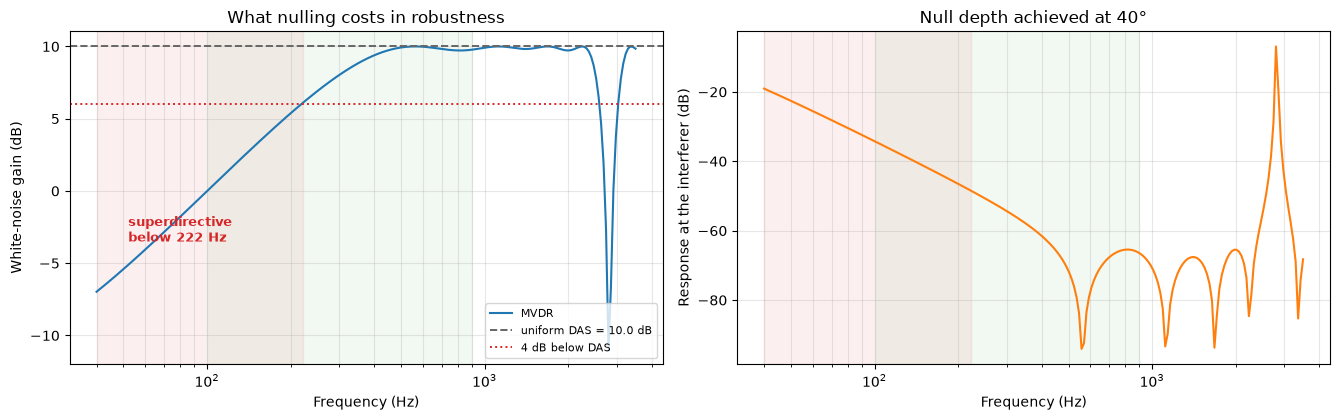

Three frequencies, and the gaps between them are the point:
    229 Hz : the interferer reaches the conventional HALF-POWER point (HPBW/2)
    222 Hz : MVDR's WNG penalty drops below 4 dB  <- measured
    562 Hz : the conventional first NULL finally reaches the interferer

MVDR becomes affordable at ~222 Hz, which tracks the half-power point
(229 Hz) and is 2.5x BELOW the 562 Hz at which DAS can null it at all.
That gap is the real benefit of going adaptive: between 222 and 562 Hz MVDR
puts a deep null on an interferer that DAS cannot resolve, at little cost. Below
~222 Hz the interferer is buried too deep inside the beam and the only solution
left is a superdirective one, which real hardware will not deliver.

Reading the sweep:
  below ~222 Hz  MVDR still nulls, but only by going superdirective. The pattern
                 is real on paper and unachievable in hardware: WNG falls to -7.0 dB at
                 40 Hz, i.e. 17 dB worse than DAS, and the
                 weights become 

In [18]:
# Continuous sweep: where adaptive beamforming is free, and where it is a trap.
f_fine = np.logspace(np.log10(40), np.log10(3500), 220)
wng_f, null_f = [], []
for f_ in f_fine:
    w, a_i = mvdr_at(float(f_))
    wng_f.append(10 * np.log10(1.0 / np.real(np.conj(w) @ w)))
    null_f.append(20 * np.log10(abs(beamformer_output(w, a_i)) + 1e-18))
wng_f, null_f = np.array(wng_f), np.array(null_f)

# Where MVDR stops being superdirective: the beam finally resolves the interferer.
ok = np.flatnonzero(wng_f >= WNG_WARN)
F_MVDR_OK = float(f_fine[ok[0]]) if ok.size else float('nan')

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
ax = axes[0]
ax.semilogx(f_fine, wng_f, label='MVDR')
ax.axhline(WNG_DAS, color='0.4', ls='--', lw=1.4, label=f'uniform DAS = {WNG_DAS:.1f} dB')
ax.axhline(WNG_WARN, color='tab:red', ls=':', lw=1.4, label=f'4 dB below DAS')
ax.axvspan(f_fine[0], F_MVDR_OK, color='tab:red', alpha=0.07)
ax.annotate(f'superdirective\nbelow {F_MVDR_OK:.0f} Hz', (52, -3.5), fontsize=9,
            color='tab:red', weight='bold')
ax.axvspan(*BAND, color='tab:green', alpha=0.06)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('White-noise gain (dB)')
ax.set_title('What nulling costs in robustness')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3, which='both')

ax = axes[1]
ax.semilogx(f_fine, null_f, color='tab:orange')
ax.axvspan(f_fine[0], F_MVDR_OK, color='tab:red', alpha=0.07)
ax.axvspan(*BAND, color='tab:green', alpha=0.06)
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel(f'Response at the interferer (dB)')
ax.set_title(f'Null depth achieved at {INTF_AZ:.0f}°')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

f_res = C_WATER / (N_LONG * D_ELEM * np.sin(np.radians(INTF_AZ)))        # null reaches 40 deg
f_hp = 0.886 * C_WATER / (N_LONG * D_ELEM * 2 * np.radians(INTF_AZ))     # HPBW/2 reaches 40 deg
print(f"Three frequencies, and the gaps between them are the point:")
print(f"  {f_hp:5.0f} Hz : the interferer reaches the conventional HALF-POWER point (HPBW/2)")
print(f"  {F_MVDR_OK:5.0f} Hz : MVDR's WNG penalty drops below 4 dB  <- measured")
print(f"  {f_res:5.0f} Hz : the conventional first NULL finally reaches the interferer")
print(f"\nMVDR becomes affordable at ~{F_MVDR_OK:.0f} Hz, which tracks the half-power point")
print(f"({f_hp:.0f} Hz) and is {f_res/F_MVDR_OK:.1f}x BELOW the {f_res:.0f} Hz at which DAS can null it at all.")
print(f"That gap is the real benefit of going adaptive: between {F_MVDR_OK:.0f} and {f_res:.0f} Hz MVDR")
print(f"puts a deep null on an interferer that DAS cannot resolve, at little cost. Below")
print(f"~{F_MVDR_OK:.0f} Hz the interferer is buried too deep inside the beam and the only solution")
print(f"left is a superdirective one, which real hardware will not deliver.")

print(f"\nReading the sweep:")
print(f"  below ~{F_MVDR_OK:.0f} Hz  MVDR still nulls, but only by going superdirective. The pattern")
print(f"                 is real on paper and unachievable in hardware: WNG falls to "
      f"{wng_f[0]:+.1f} dB at")
print(f"                 {f_fine[0]:.0f} Hz, i.e. {WNG_DAS - wng_f[0]:.0f} dB worse than DAS, and the")
print(f"                 weights become hypersensitive to the channel errors of section 14.")
print(f"  {F_MVDR_OK:.0f}-{F_ALIAS:.0f} Hz   MVDR is essentially free: a {np.median(null_f[(f_fine>F_MVDR_OK)&(f_fine<F_ALIAS)]):.0f} dB null at no WNG cost.")
print(f"                 This is the band where adaptive beamforming is clearly worth it.")
print(f"  above {F_ALIAS_BS:.0f} Hz  WNG degrades again, for a DIFFERENT reason: the interferer now sits")
print(f"                 near a grating-lobe replica of the look direction, so nulling it fights")
print(f"                 the main lobe. Same symptom as the low end, opposite cause.")

assert wng_f[0] < WNG_WARN, "Regression: MVDR must be superdirective at the low end"
assert abs(np.median(wng_f[(f_fine > 500) & (f_fine < 1500)]) - WNG_DAS) < 1.0, \
    "Regression: in the clean band MVDR should cost essentially no white-noise gain"
print("\n[OK] Superdirective at low frequency, free in the clean band.")


### 15.3 The Same Sweep with an Amplitude Taper

*Ideal baseline — supports: whether to taper, and over what band.*

§13 showed that on a URA — unlike the ring — an amplitude taper does what the textbook
promises: at f₀ a Hann window drops the peak sidelobe from −12.0 dB to −33.6 dB for about
1 dB of array gain. That was a **single frequency**. Sweeping it reveals that the taper is
useful over a **narrower band than the array itself**, and for two quite different reasons at
the two ends.

One thing that does *not* vary: the weights are fixed numbers on fixed elements, so the
**white-noise gain cost is frequency-independent** — Hann −0.97 dB, Hamming −2.02 dB,
Chebyshev −0.53 dB, at every frequency. You pay it whether or not you get anything back.

What the sweep has to answer is therefore: **over what band do you get anything back?**

Two failure modes bracket the useful band, and neither is obvious from the f₀ result:

* **At the bottom**, there are no sidelobes to suppress. Below ~361 Hz the aperture is
  shorter than a wavelength and no sidelobe structure exists; by 500 Hz the Hann main lobe is
  so broad it fills the entire forward sector. The taper is pure loss.
* **At the top**, a taper **cannot touch a grating lobe**. A grating lobe is a full-height
  *replica of the main lobe*, not a sidelobe — the taper shapes the main lobe and every
  replica identically, so the replica stays at 0 dB. Worse, widening the main lobe also
  widens the replica, pulling it into visible space *sooner*.

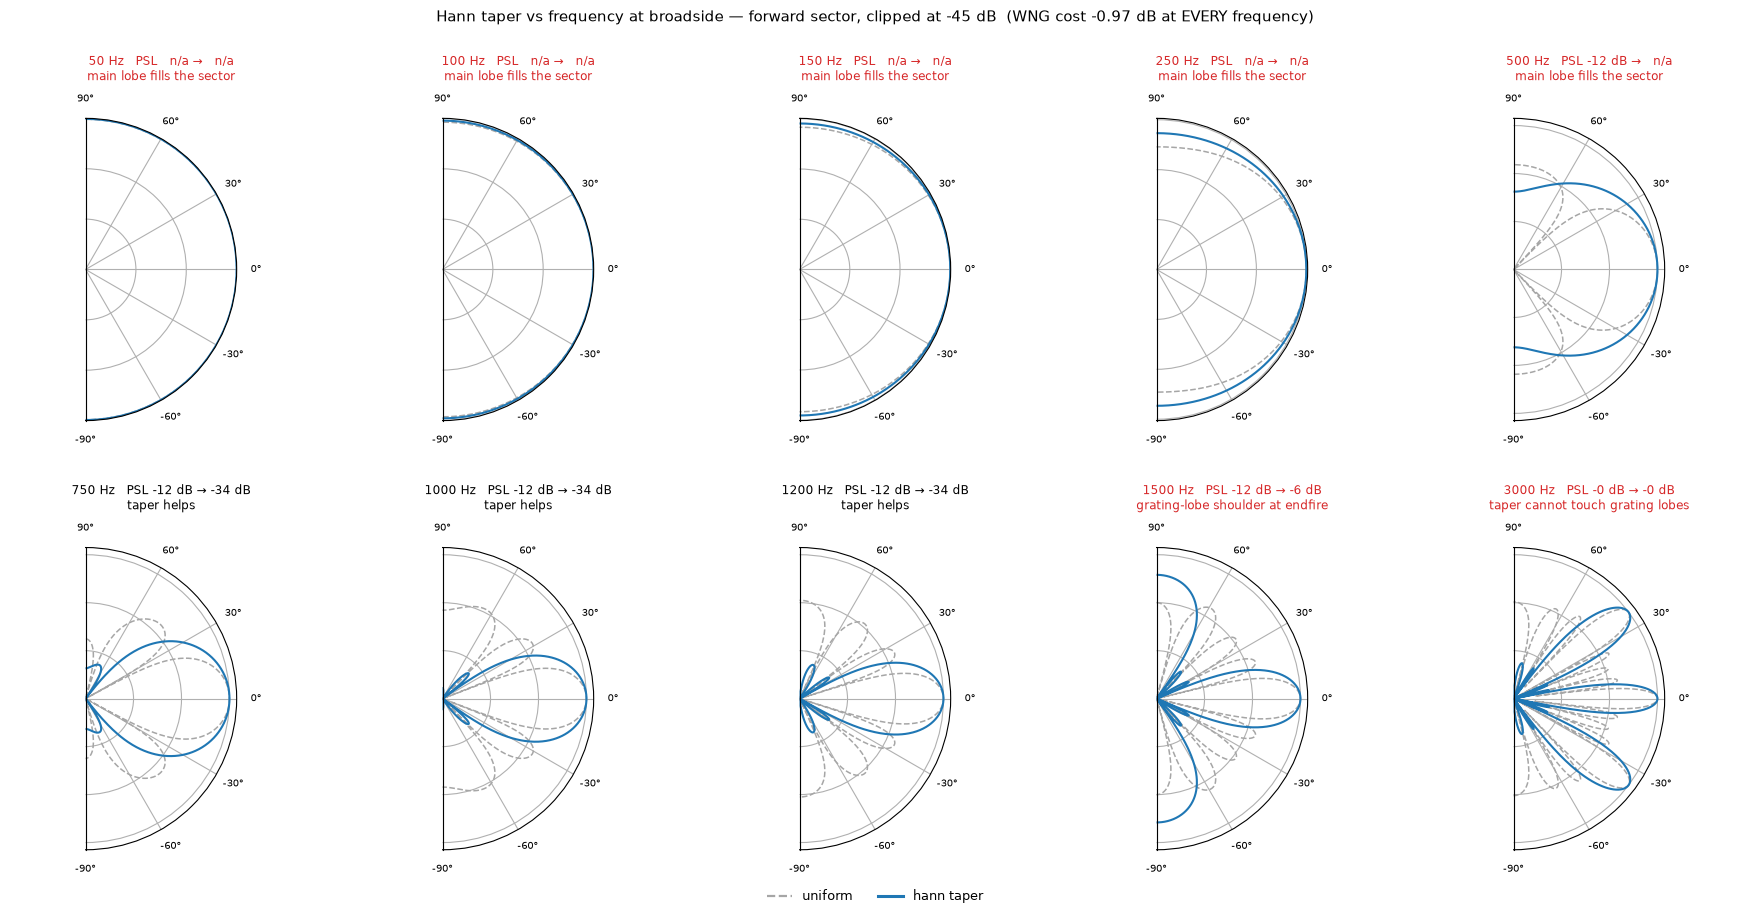

White-noise gain cost (fixed weights -> same at every frequency):
  uniform   : +0.00 dB
  hamming   : -2.02 dB
  hann      : -0.97 dB
  chebyshev : -0.53 dB

 f (Hz) |  PSL unif |  PSL hann |     gain |     HPBW u->t | outcome
----------------------------------------------------------------------------------------------------
     50 |       n/a |       n/a |      n/a |    n/a -> n/a | main lobe fills the sector
    100 |       n/a |       n/a |      n/a |    n/a -> n/a | main lobe fills the sector
    150 |       n/a |       n/a |      n/a |    n/a -> n/a | main lobe fills the sector
    250 |       n/a |       n/a |      n/a |   81° -> 121° | main lobe fills the sector
    500 |  -12.2 dB |       n/a |      n/a |    38° -> 51° | main lobe fills the sector
    750 |  -12.0 dB |  -33.6 dB |   -21.6 |    25° -> 34° | taper helps
   1000 |  -12.0 dB |  -33.6 dB |   -21.6 |    19° -> 25° | taper helps
   1200 |  -12.0 dB |  -33.6 dB |   -21.6 |    15° -> 21° | taper helps
   1500 |  -12.

In [19]:
TAPER_MAIN = 'hann'          # best sidelobe/efficiency trade at f0 (section 13)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')     # chebwin's spectral-analysis warning; see section 13
    TAPS = {t: make_taper(t) for t in ['uniform', 'hamming', 'hann', 'chebyshev']}
TAPER_EFF = {t: 10 * np.log10(g.sum()**2 / (len(g) * np.sum(g**2))) for t, g in TAPS.items()}


def psl_of(f_, taper, search=89.0):
    '''Forward-sector peak sidelobe; NaN when the main lobe fills the sector.'''
    pdb = to_db_norm(beam_pattern(0.0, 0.0, float(f_), amp=TAPS[taper]))
    return lobe_metrics(PHI_GRID[FWD], pdb[FWD], 0.0, circular=False, search=search), pdb


fig, axes = plt.subplots(2, 5, figsize=(18, 9.0), subplot_kw={'projection': 'polar'})
rows_t = []
for ax, f_ in zip(axes.ravel(), sweep_f):
    m_u, pdb_u = psl_of(f_, 'uniform')
    m_t, pdb_t = psl_of(f_, TAPER_MAIN)
    npk_u, npk_t = fwd_peak_count(pdb_u), fwd_peak_count(pdb_t)

    helps = (np.isfinite(m_u['psl']) and np.isfinite(m_t['psl'])
             and m_t['psl'] < m_u['psl'] - 3.0)
    if npk_t > 1:
        why = 'taper cannot touch grating lobes'
    elif not np.isfinite(m_t['psl']):
        why = 'main lobe fills the sector'
    elif not helps:
        why = 'grating-lobe shoulder at endfire'
    else:
        why = ''

    ax.plot(np.radians(PHI_GRID), np.clip(pdb_u, -45, 0) + 45, '--', color='0.65', lw=1.1)
    ax.plot(np.radians(PHI_GRID), np.clip(pdb_t, -45, 0) + 45, color='tab:blue')
    ax.set_theta_zero_location('E'); ax.set_thetamin(-90); ax.set_thetamax(90)
    ax.set_yticks([15, 30, 45]); ax.set_yticklabels([])
    ax.set_thetagrids([-90, -60, -30, 0, 30, 60, 90], fontsize=7)
    f_u = '  n/a' if not np.isfinite(m_u['psl']) else f"{m_u['psl']:.0f} dB"
    f_t = '  n/a' if not np.isfinite(m_t['psl']) else f"{m_t['psl']:.0f} dB"
    ax.set_title(f"{f_} Hz   PSL {f_u} → {f_t}\n"
                 f"{'taper helps' if helps else why}",
                 fontsize=8.5, color='k' if helps else 'tab:red', pad=10)
    rows_t.append((f_, m_u['psl'], m_t['psl'], m_u['hpbw'], m_t['hpbw'], npk_t, helps, why))

h = [plt.Line2D([], [], color='0.65', ls='--', lw=1.6, label='uniform'),
     plt.Line2D([], [], color='tab:blue', lw=2.2, label=f'{TAPER_MAIN} taper')]
fig.legend(handles=h, loc='lower center', ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.015))
fig.suptitle(f'{TAPER_MAIN.capitalize()} taper vs frequency at broadside — forward sector, '
             f'clipped at -45 dB  (WNG cost {TAPER_EFF[TAPER_MAIN]:+.2f} dB at EVERY frequency)',
             fontsize=11, y=0.99)
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.subplots_adjust(hspace=0.42)
plt.show()

print(f"White-noise gain cost (fixed weights -> same at every frequency):")
for t, e in TAPER_EFF.items():
    print(f"  {t:10}: {e:+.2f} dB")

print(f"\n{'f (Hz)':>7} | {'PSL unif':>9} | {'PSL ' + TAPER_MAIN:>9} | {'gain':>8} | "
      f"{'HPBW u->t':>13} | outcome")
print('-' * 100)
for f_, pu, pt, hu, ht, npk, helps, why in rows_t:
    fu = '      n/a' if not np.isfinite(pu) else f"{pu:6.1f} dB"
    ft = '      n/a' if not np.isfinite(pt) else f"{pt:6.1f} dB"
    g = '     n/a' if not (np.isfinite(pu) and np.isfinite(pt)) else f"{pt - pu:+7.1f}"
    hw = ('  n/a' if not np.isfinite(hu) else f"{hu:.0f}°") + ' -> ' + \
         ('n/a' if not np.isfinite(ht) else f"{ht:.0f}°")
    print(f"{f_:>7} | {fu} | {ft} | {g} | {hw:>13} | {'taper helps' if helps else why}")


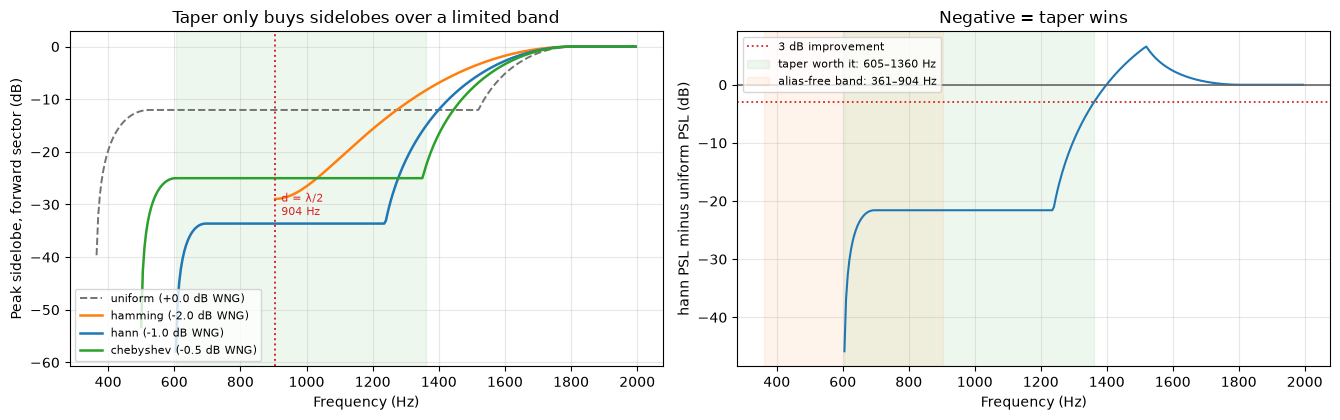

Hann beats uniform by >3 dB from 605 to 1360 Hz.
The array's own alias-free band is 361-904 Hz.

These two bands are NOT the same, and their overlap 605-904 Hz is where this
panel is genuinely at its best: alias-free at any steer AND tapering usefully.

The two failure modes, which are different problems:
  below 605 Hz : nothing to suppress. At 500 Hz the hann main lobe is already
                 wider than the forward sector, so there is no sidelobe left to lower --
                 the taper just spends 1.0 dB of array gain for nothing.
  above 1360 Hz: the grating-lobe replica. A taper shapes the main lobe, and a grating
                 lobe IS the main lobe repeated -- so it is shaped identically and stays at
                 full height. At 3 kHz uniform and hann both leave 3 peaks at 0 dB.
                 Widening the main lobe widens the replica too, so from ~1400 Hz the taper
                 actually pulls grating-lobe energy into view EARLIER than uniform does.

[OK] Tape

In [20]:
# Over what band is the taper actually worth its gain cost?
f_t = np.arange(250.0, 2000.0, 5.0)
psl_curves = {}
for t in ['uniform', 'hamming', 'hann', 'chebyshev']:
    vals = []
    for f_ in f_t:
        pdb = to_db_norm(beam_pattern(0.0, 0.0, float(f_), amp=TAPS[t]))
        vals.append(lobe_metrics(PHI_GRID[FWD], pdb[FWD], 0.0, circular=False,
                                 search=89.0)['psl'])
    psl_curves[t] = np.array(vals, dtype=float)

base = psl_curves['uniform']
adv = psl_curves[TAPER_MAIN] - base            # negative = taper is better
usable = np.flatnonzero(np.isfinite(adv) & (adv < -3.0))
F_TAP_LO, F_TAP_HI = float(f_t[usable[0]]), float(f_t[usable[-1]])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))
ax = axes[0]
for t, col in zip(['uniform', 'hamming', 'hann', 'chebyshev'],
                  ['0.45', 'tab:orange', 'tab:blue', 'tab:green']):
    ax.plot(f_t, psl_curves[t], color=col, lw=1.8 if t != 'uniform' else 1.4,
            ls='--' if t == 'uniform' else '-',
            label=f'{t} ({TAPER_EFF[t]:+.1f} dB WNG)')
ax.axvspan(F_TAP_LO, F_TAP_HI, color='tab:green', alpha=0.08)
ax.axvline(F_ALIAS, color='tab:red', ls=':', lw=1.4)
ax.annotate(f'd = λ/2\n{F_ALIAS:.0f} Hz', (F_ALIAS + 20, -32), fontsize=8, color='tab:red')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Peak sidelobe, forward sector (dB)')
ax.set_title('Taper only buys sidelobes over a limited band')
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(f_t, adv, color='tab:blue')
ax.axhline(0, color='0.4', lw=1.2)
ax.axhline(-3, color='tab:red', ls=':', lw=1.3, label='3 dB improvement')
ax.axvspan(F_TAP_LO, F_TAP_HI, color='tab:green', alpha=0.08,
           label=f'taper worth it: {F_TAP_LO:.0f}–{F_TAP_HI:.0f} Hz')
ax.axvspan(f_no_null, F_ALIAS, color='tab:orange', alpha=0.08,
           label=f'alias-free band: {f_no_null:.0f}–{F_ALIAS:.0f} Hz')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(f'{TAPER_MAIN} PSL minus uniform PSL (dB)')
ax.set_title('Negative = taper wins')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

lo_i, hi_i = max(F_TAP_LO, f_no_null), min(F_TAP_HI, F_ALIAS)
print(f"{TAPER_MAIN.capitalize()} beats uniform by >3 dB from {F_TAP_LO:.0f} to {F_TAP_HI:.0f} Hz.")
print(f"The array's own alias-free band is {f_no_null:.0f}-{F_ALIAS:.0f} Hz.")
print(f"\nThese two bands are NOT the same, and their overlap {lo_i:.0f}-{hi_i:.0f} Hz is where this")
print(f"panel is genuinely at its best: alias-free at any steer AND tapering usefully.")
print(f"\nThe two failure modes, which are different problems:")
print(f"  below {F_TAP_LO:.0f} Hz : nothing to suppress. At 500 Hz the {TAPER_MAIN} main lobe is already")
print(f"                 wider than the forward sector, so there is no sidelobe left to lower --")
print(f"                 the taper just spends {abs(TAPER_EFF[TAPER_MAIN]):.1f} dB of array gain for nothing.")
print(f"  above {F_TAP_HI:.0f} Hz: the grating-lobe replica. A taper shapes the main lobe, and a grating")
print(f"                 lobe IS the main lobe repeated -- so it is shaped identically and stays at")
print(f"                 full height. At 3 kHz uniform and {TAPER_MAIN} both leave "
      f"{rows_t[-1][5]} peaks at 0 dB.")
print(f"                 Widening the main lobe widens the replica too, so from ~1400 Hz the taper")
print(f"                 actually pulls grating-lobe energy into view EARLIER than uniform does.")

i3k = sweep_f.index(3000)
assert rows_t[i3k][5] > 1 and not rows_t[i3k][6], \
    "Regression: a taper must NOT fix grating lobes at 3 kHz"
assert F_TAP_LO > f_no_null, \
    "Regression: the taper's useful band must start above the no-null cutoff"
print("\n[OK] Taper helps only between the two failure modes, and never against aliasing.")


## 16. Broadband Ship Noise Model

*Ideal baseline — supports: signal model reused by the realistic revision.*

The same freight-ship signature used for the ring, so the two arrays are driven by identical
sources. For this panel the band splits into three regions:

* **below ~361 Hz** — the long aperture is shorter than a wavelength; no azimuth discrimination;
* **361–904 Hz** — the useful bearing band, alias-free at any steer;
* **above 904 Hz** — steering-dependent grating lobes.

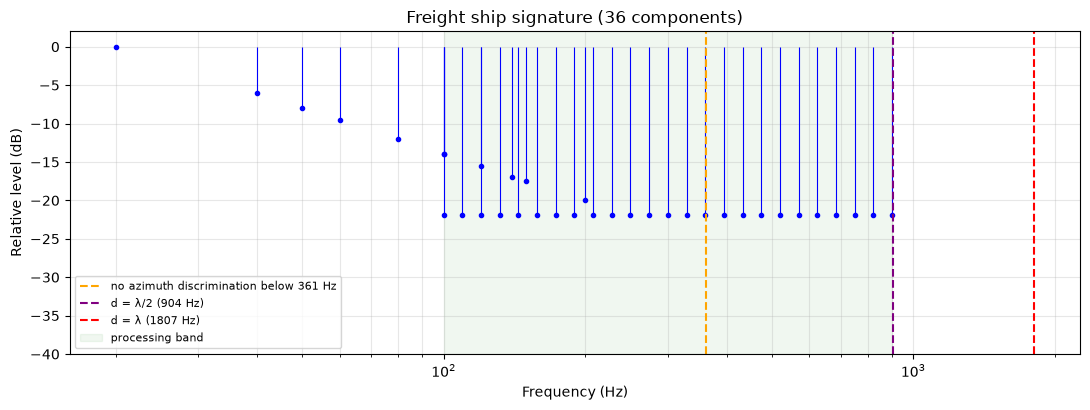

Ship model: 36 components, 20-900 Hz
    20 Hz: lambda =  75.00 m, lambda/Nd = 18.07, null = none
   100 Hz: lambda =  15.00 m, lambda/Nd =  3.61, null = none
   355 Hz: lambda =   4.23 m, lambda/Nd =  1.02, null = none
   400 Hz: lambda =   3.75 m, lambda/Nd =  0.90, null = 64.6 deg
   600 Hz: lambda =   2.50 m, lambda/Nd =  0.60, null = 37.0 deg
   904 Hz: lambda =   1.66 m, lambda/Nd =  0.40, null = 23.6 deg


In [21]:
from ura2x5.noise import ship_noise_model as _ship_noise_model
ship_noise_model = partial(_ship_noise_model, band=BAND)

ship_spec = ship_noise_model()
freqs_s = np.array([f for f, a in ship_spec]); amps = np.array([a for f, a in ship_spec])

fig, ax = plt.subplots(figsize=(11, 4.2))
ml, sl, bl = ax.stem(freqs_s, 20*np.log10(amps/amps.max() + 1e-12),
                     linefmt='b-', markerfmt='bo', basefmt=' ')
ml.set_markersize(3); sl.set_linewidth(0.8)
ax.set_xscale('log'); ax.set_ylim(-40, 2)
ax.axvline(f_no_null, color='orange', ls='--', label=f'no azimuth discrimination below {f_no_null:.0f} Hz')
ax.axvline(F_ALIAS, color='purple', ls='--', label=f'd = λ/2 ({F_ALIAS:.0f} Hz)')
ax.axvline(F_ALIAS_BS, color='r', ls='--', label=f'd = λ ({F_ALIAS_BS:.0f} Hz)')
ax.axvspan(*BAND, color='green', alpha=0.06, label='processing band')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Relative level (dB)')
ax.set_title(f'Freight ship signature ({len(ship_spec)} components)')
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f'Ship model: {len(ship_spec)} components, {freqs_s.min():.0f}-{freqs_s.max():.0f} Hz')
for f_ in [20, 100, 355, 400, 600, 904]:
    tn = float(theta_null_line_deg(f_))
    print(f'  {f_:>4} Hz: lambda = {C_WATER/f_:6.2f} m, lambda/Nd = {C_WATER/f_/(N_LONG*D_ELEM):5.2f}, '
          f'null = {"none" if not np.isfinite(tn) else f"{tn:.1f} deg"}')


## 17. Bearing Tracking — Moving Ship, and a Loud Ship Astern

*Ideal baseline — supports: the ideal processing term of the bearing budget; the baffle spec.*

A ship crosses the panel's forward sector from −60° to +60° over 50 updates. Each update
simulates 16 snapshots in each of 20 bins across 300–900 Hz, forms a per-bin covariance, scans
azimuth and sums power incoherently.

A second, **louder ship sits astern at 150°**. Its mirror bearing is 30° — inside the forward
sector — so it is precisely the case the back baffle exists to defeat. Both the baffled and
unbaffled cases are run, so the baffle's contribution is measured rather than assumed.

Note what the baffle does *not* do: every source still paints **two** peaks, because the
manifold is degenerate (§5). Reporting the forward one is a convention, and the baffle is what
makes that convention safe.

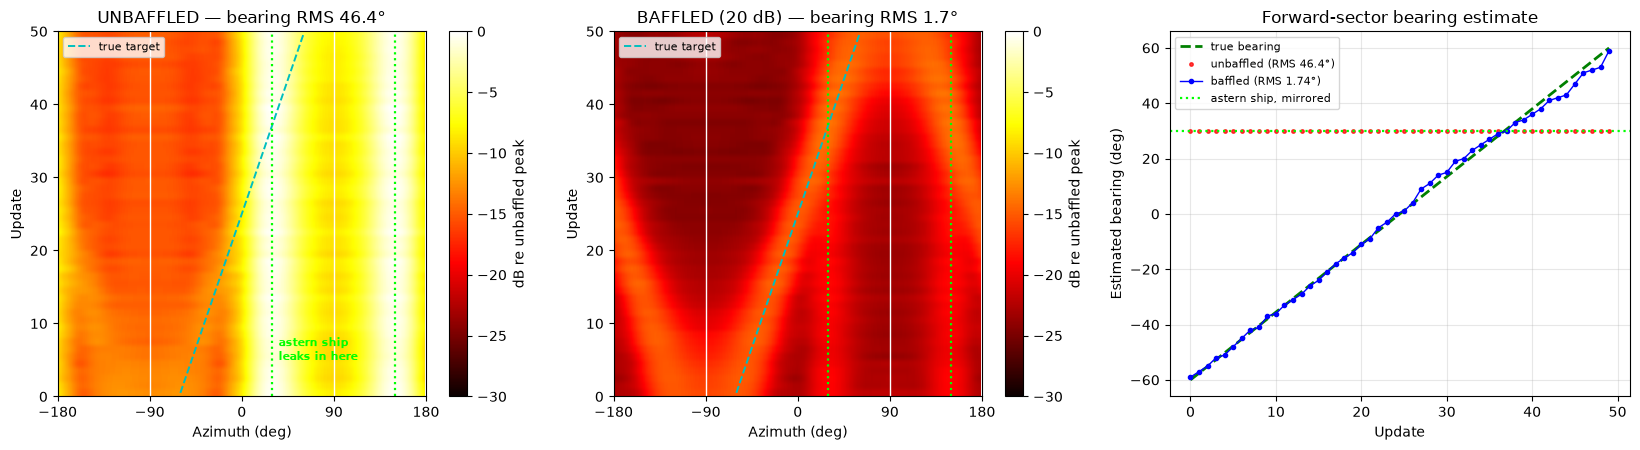

Both BTR panels share one colour scale (dB relative to the unbaffled peak), so
the drop between them is the baffle doing its job, not a change of normalisation.
  peak scanned power, unbaffled :  +0.0 dB
  peak scanned power, baffled   : -13.8 dB

Band 300-900 Hz, 20 bins x 16 snapshots
Target ahead at 0 dB; ship astern at 150° (+15 dB), mirroring into 30°

      case |  astern ship arrives at |  bearing RMS |  updates captured
------------------------------------------------------------------------
 unbaffled |                +15.0 dB |       46.36° |         50 / 50
   baffled |                 -5.0 dB |        1.74° |          5 / 50

Unbaffled, the ship astern is 15 dB louder than the wanted target, so its mirror
image at 30° dominates the forward sector and the estimate is captured by a ship
that is not even on this side of the panel. The 20 dB baffle brings it to -5 dB,
below the real target, and the track is recovered.

That is the concrete value of the baffle, and why its front

In [22]:
bins_tr = np.linspace(300, BAND[1], 20)
snr_db, n_snap_bin, n_updates = 0.0, 16, 50
phi_true = np.linspace(-60, 60, n_updates)
phi_scan = np.arange(-180.0, 180.0, 1.0)
FWD_SCAN = (phi_scan >= -90) & (phi_scan <= 90)
A_bins = {f_: steering_vector(0.0, phi_scan, f_) for f_ in bins_tr}

# A loud ship ASTERN whose mirror bearing lands inside the forward sector. This is the exact
# failure the back baffle exists to prevent, and the only way to show what it is worth.
ASTERN_AZ, ASTERN_SNR = 150.0, 15.0
ASTERN_MIRROR = float(mirror_azimuth_deg(ASTERN_AZ))


def run_track(fbr_db):
    rng = np.random.default_rng(42)
    atten = float(baffle_response(ASTERN_AZ, fbr_db, transition_deg=FBR_TRANS))
    eff = ASTERN_SNR + 20 * np.log10(max(atten, 1e-9))
    est, maps = [], []
    for p_src in phi_true:
        P = np.zeros(len(phi_scan))
        for f_ in bins_tr:
            R = sample_covariance(simulate_snapshots(
                [(0.0, p_src, snr_db), (0.0, ASTERN_AZ, eff)], f_, n_snap_bin, rng))
            A = A_bins[f_]
            P += np.real(np.sum(np.conj(A) * (R @ A), axis=0)) / N**2
        maps.append(P)          # unnormalised; both cases share one scale below
        est.append(phi_scan[FWD_SCAN][np.argmax(P[FWD_SCAN])])
    return np.array(est), np.array(maps), eff


est_baf, maps_baf, eff_baf = run_track(FBR_DB)
est_un, maps_un, eff_un = run_track(0.0)

# One reference for both panels, so the colour scale means the same thing in each.
REF = maps_un.max()
maps_baf, maps_un = maps_baf / REF, maps_un / REF
rms_baf = float(np.sqrt(np.mean(wrap180(est_baf - phi_true) ** 2)))
rms_un = float(np.sqrt(np.mean(wrap180(est_un - phi_true) ** 2)))

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
k = np.arange(n_updates)
for ax, mp, lab, rr in [(axes[0], maps_un, 'UNBAFFLED', rms_un),
                        (axes[1], maps_baf, f'BAFFLED ({FBR_DB:.0f} dB)', rms_baf)]:
    im = ax.imshow(10 * np.log10(mp), aspect='auto', origin='lower', vmin=-30, vmax=0,
                   extent=[phi_scan[0], phi_scan[-1], 0, n_updates], cmap='hot')
    ax.plot(phi_true, k + 0.5, 'c--', lw=1.4, label='true target')
    ax.axvline(ASTERN_MIRROR, color='lime', ls=':', lw=1.6)
    ax.axvline(ASTERN_AZ, color='lime', ls=':', lw=1.6)
    ax.axvline(-90, color='w', lw=1); ax.axvline(90, color='w', lw=1)
    ax.set_xticks(range(-180, 181, 90)); ax.set_xlabel('Azimuth (deg)')
    ax.set_ylabel('Update'); ax.set_title(f'{lab} — bearing RMS {rr:.1f}°')
    ax.legend(fontsize=8, loc='upper left')
    plt.colorbar(im, ax=ax, label='dB re unbaffled peak')
axes[0].annotate('astern ship\nleaks in here', (ASTERN_MIRROR + 6, 5), fontsize=8,
                 color='lime', weight='bold')

axes[2].plot(k, phi_true, 'g--', lw=2, label='true bearing')
axes[2].plot(k, est_un, 'r.', ms=5, alpha=0.75, label=f'unbaffled (RMS {rms_un:.1f}°)')
axes[2].plot(k, est_baf, 'b.-', lw=1, label=f'baffled (RMS {rms_baf:.2f}°)')
axes[2].axhline(ASTERN_MIRROR, color='lime', ls=':', lw=1.6, label='astern ship, mirrored')
axes[2].set_xlabel('Update'); axes[2].set_ylabel('Estimated bearing (deg)')
axes[2].set_title('Forward-sector bearing estimate')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Both BTR panels share one colour scale (dB relative to the unbaffled peak), so')
print(f'the drop between them is the baffle doing its job, not a change of normalisation.')
print(f'  peak scanned power, unbaffled : {10*np.log10(maps_un.max()):+5.1f} dB')
print(f'  peak scanned power, baffled   : {10*np.log10(maps_baf.max()):+5.1f} dB\n')

cap_un = int(np.sum(np.abs(wrap180(est_un - ASTERN_MIRROR)) < 5.0))
cap_bf = int(np.sum(np.abs(wrap180(est_baf - ASTERN_MIRROR)) < 5.0))
print(f'Band {bins_tr[0]:.0f}-{bins_tr[-1]:.0f} Hz, {len(bins_tr)} bins x {n_snap_bin} snapshots')
print(f'Target ahead at {snr_db:.0f} dB; ship astern at {ASTERN_AZ:.0f}° '
      f'({ASTERN_SNR:+.0f} dB), mirroring into {ASTERN_MIRROR:.0f}°\n')
print(f"{'case':>10} | {'astern ship arrives at':>23} | {'bearing RMS':>12} | {'updates captured':>17}")
print('-' * 72)
print(f"{'unbaffled':>10} | {eff_un:+20.1f} dB | {rms_un:11.2f}° | {cap_un:>10} / {n_updates}")
print(f"{'baffled':>10} | {eff_baf:+20.1f} dB | {rms_baf:11.2f}° | {cap_bf:>10} / {n_updates}")

print(f'\nUnbaffled, the ship astern is {ASTERN_SNR:.0f} dB louder than the wanted target, so its mirror')
print(f'image at {ASTERN_MIRROR:.0f}° dominates the forward sector and the estimate is captured by a ship')
print(f'that is not even on this side of the panel. The {FBR_DB:.0f} dB baffle brings it to '
      f'{eff_baf:+.0f} dB,')
print(f'below the real target, and the track is recovered.')
print(f'\nThat is the concrete value of the baffle, and why its front-to-back rejection is an')
print(f'ACOUSTIC REQUIREMENT rather than an installation detail: the margin needed is set by')
print(f'how much louder a ship astern may plausibly be (section 5).')
assert rms_baf < 2.0, "Regression: baffled tracking should be accurate at 0 dB SNR"
assert rms_un > 5 * rms_baf, "Regression: the unbaffled case must be captured by the astern ship"


## 18. Summary — 2×5 Panel vs the 9-Element Ring

The two arrays are near-opposites. Neither is better overall; they fail in different places.

| | **9-element ring** (BEAMFORM_LEN) | **2×5 panel** (this notebook) |
|---|---|---|
| Elements | 9 | 10 |
| Aperture | 1.25 m diameter | 3.32 m × 0.83 m |
| Element spacing | 0.4275 m chord | **0.83 m** |
| White-noise array gain | 9.5 dB | **10.0 dB** |
| HPBW at own f₀ | 41.4° (at 1200 Hz) | **20.6°** (at 904 Hz) |
| Peak sidelobe | −7.9 dB (intrinsic) | **−12.0 dB**, → **−33 dB** tapered |
| Amplitude taper | **harmful** (PSL → −3.7 dB) | **effective** (PSL → −33.6 dB) |
| Azimuth coverage | **full 360°**, steering-invariant | **≈ ±45° per panel**, one face only |
| Ambiguity | up/down (unresolved) | front/back, **resolved by the back baffle** |
| Overhead (host) rejection | poor: −1.4 dB at 300 Hz | **null at f₀**, poor at low f |
| Alias-free to | **1754 Hz** | **904 Hz** (any steer) / 1807 Hz (broadside) |
| No azimuth discrimination below | 459 Hz | 361 Hz |

### What this notebook establishes

1. **Resolution and sidelobes are much better.** 20.6° versus 41.4°, −12 dB versus −7.9 dB,
   and unlike the ring the panel responds to tapering — Hamming reaches −28.9 dB and Hann
   −33.6 dB for about 1–2 dB of array gain. Sidelobe control is a solved problem here, where
   on the ring it needs phase-mode weighting.
2. **Coverage is the price.** One panel covers roughly ±45° of its front face. Full 360°
   coverage therefore needs about four baffled panels — against a single ring that covers the
   whole horizon with nine elements. The baffle removes the ambiguity but does not add
   coverage: it defines which half is usable.
3. **The front/back ambiguity is exact, and the back baffle is what handles it.** The mirror
   arrival produces an identical steering vector, so no processor can separate the pair — the
   baffle works by attenuating the back arrival before it reaches the elements, not by
   resolving it afterwards. That makes baffle performance a **primary acoustic requirement**
   rather than an installation detail: at the placeholder 20 dB, a source 30 dB louder astern
   still shows as a false contact above the sidelobe floor. §5 gives the requirement as
   FBR ≥ (loudest source astern, relative) + (wanted margin).
4. **Spatial sampling is the binding constraint.** 0.83 m spacing is nearly twice the ring's,
   which halves the clean band. The practical statement is the two-threshold one in §15: fully
   steerable below 904 Hz, broadside-only up to 1807 Hz.
5. **The baffle should also buy array gain, which this notebook does not credit.** Blocking
   the rear halves the solid angle of arriving ambient noise, worth up to **+3 dB** against an
   isotropic field. The ideal baseline here assumes spatially *white* noise, for which
   blocking directions changes nothing, so the benefit does not appear. It belongs in the
   realistic-conditions revision alongside the correlated-noise models.
6. **Overhead rejection is excellent but narrowband.** The 2-element stack nulls the zenith at
   f₀ — far better than the ring, whose host problem is severe — but the null is tied to the
   vertical spacing and does not hold at the bottom of the band.

### Next steps

* **A realistic-condition revision**, as was done for the ring: correlated ocean noise,
  host-platform noise, channel and position errors, ADC skew, heading, multipath, a real
  detector and a tracker. The shared `ura2x5/` core already carries those modules.
* **Measure the installed baffle's front-to-back rejection, across the band.** §5 turns that
  single number into a pass/fail; the 20 dB used here is a placeholder, and real baffles fall
  off at low frequency where this array is already weakest.
* **Decide the panel count and layout** for the required coverage, using the ±45° sector and
  the front/back constraint from §5 and §14.
* **Check the 0.83 m spacing against the required band.** If bearings are wanted above
  904 Hz, the spacing is the thing to change — no amount of processing recovers a grating lobe.
